<a href="https://colab.research.google.com/github/PratikshitSingh/AI-Model-Evaluation---Training/blob/main/module_06_lab_agent_production.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Lab: Evaluating Agentic Systems with LangGraph & LangChain

## Module 06 — Agent Evaluation Using Real Agent Infrastructure 🛠️

---

> 💰 **This lab is 100% free.** No API keys, no paid accounts, no cloud credits. Everything runs locally using open-source Python packages (`langgraph`, `langchain-core`, `pandas`, `numpy`). The agent uses a simulated planner instead of a real LLM, so you get **reproducible, deterministic** results every time — and it costs nothing. Just run the cells.

---

## 🎯 Overview

In this lab, you will **build a real LangGraph agent** — a travel booking assistant — and then **systematically tear apart its behavior** using a multi-layered evaluation pipeline. This isn't theory — you'll write evaluation code that catches real failure modes.

Unlike labs that use pre-built trajectory data, here you will:

1. **Build** a working agent using LangGraph's `StateGraph` with real tool definitions via LangChain
2. **Run** the agent against 10 carefully-designed test scenarios and capture full execution traces
3. **Evaluate** tool selection, input validity, trajectory quality, and outcome correctness — layer by layer
4. **Discover** that a passing outcome can hide a dangerous path (the most important lesson in agent eval)

### Why This Lab Matters

In production, agents make **sequences of decisions** — call this tool, pass these inputs, interpret this output, decide what to do next. A single bad decision at step 2 can cascade into a catastrophic outcome at step 5. Traditional LLM evaluation (accuracy, BLEU) can't catch this. You need **trajectory-level evaluation**, and that's exactly what you'll build here.

> 💡 **Why LangGraph?** LangGraph gives you a *graph-based* framework for building agents. Each agent decision is a node in a graph, tool execution is another node, and edges define the flow. This structure makes it **naturally inspectable** — every step is a discrete, observable event. That's exactly what you need for evaluation.

### 🏗️ What You'll Build

```
┌─────────────────────────────────────────────────────────────────────┐
│                LANGGRAPH AGENT + EVALUATION PIPELINE                │
│                                                                     │
│  Part 1: BUILD THE AGENT                                           │
│  ┌───────────┐     ┌───────────┐     ┌───────────┐                │
│  │  Define    │────▶│  Build    │────▶│  Compile  │                │
│  │  Tools     │     │  Graph    │     │  & Run    │                │
│  │ (LangChain)│     │(LangGraph)│     │  Agent    │                │
│  └───────────┘     └───────────┘     └───────────┘                │
│                                                                     │
│  Part 2: EVALUATE THE AGENT                                        │
│  ┌───────────┐     ┌───────────┐     ┌───────────┐                │
│  │  Capture   │────▶│  Score    │────▶│  Root     │                │
│  │  Traces    │     │Trajectories│    │  Cause    │                │
│  │            │     │           │     │  Analysis │                │
│  └───────────┘     └───────────┘     └───────────┘                │
└─────────────────────────────────────────────────────────────────────┘
```

## 📚 Learning Objectives

After completing this lab, you will be able to:

1. Build a tool-calling agent using LangGraph's `StateGraph` and LangChain's `@tool` decorator
2. Capture and inspect agent execution traces (every tool call, every input, every output)
3. Evaluate tool selection accuracy using precision and recall — and explain what each reveals
4. Validate tool inputs at both schema and semantic levels
5. Score trajectories across multiple dimensions (not just "did it work?")
6. Explain why path quality ≠ outcome quality — the single most important concept in agent evaluation
7. Perform root cause analysis that pinpoints *exactly where* an agent went wrong
8. Detect looping vs. productive retries programmatically

## 🧩 Prerequisites

- Module 01 (Modern AI Evaluation Foundations)
- Module 02 (Failure Mode Analysis)
- Basic Python (dicts, lists, functions, classes)
- Conceptual understanding of LLM tool calling (we'll explain everything else)

## ⏱️ Estimated Time

**35–45 minutes** hands-on

## 🎬 Scenario

You are an ML engineer evaluating a **travel booking agent**. The agent has access to three tools:

| Tool | Purpose | Key Inputs |
|------|---------|------------|
| `flight_search` | Search for available flights | origin, destination, date, passengers |
| `hotel_booking` | Book hotel rooms | city, check_in, check_out, guests, budget |
| `calendar_check` | Check calendar availability | user_id, date_range_start, date_range_end |

You will build this agent in LangGraph, run it against 10 test cases that are *designed to fail in specific ways*, and evaluate every aspect of its behavior — from tool selection to final answer quality.

> ⚠️ **Key Design Decision:** We use a *simulated* planner (scenario lookup table) instead of a real LLM call. This isn't a shortcut — it's a deliberate engineering choice. Simulated scenarios give you **reproducible, deterministic** test cases where you control exactly which failures appear. In production, you'd swap in a real LLM and add LangSmith/Langfuse for tracing — but the evaluation code you write here works identically on real traces.

---

## 🔧 Task 1: Environment Setup

### Goal
Install and import all required packages.

### What You Need (All Free, All Open-Source)

| Package | What It Does | License |
|---------|-------------|---------|
| `langgraph` | Graph-based agent framework | MIT |
| `langchain-core` | Tool definitions, message types | MIT |
| `pandas` | Data analysis for evaluation results | BSD-3 |
| `numpy` | Numerical computations for scoring | BSD-3 |

**No API keys. No paid accounts. No cloud credits.** Everything runs in your notebook runtime (Colab, Jupyter, or VS Code). If you're using Google Colab, you already have a free account — just open this notebook and start running cells.

### Steps
Run the two cells below to install packages and import everything.

In [ ]:
%%capture
# Install all required packages
# %%capture hides the verbose pip output so your notebook stays clean
!pip install langgraph langchain-core pandas numpy

In [ ]:
# ============================================================
# Core Imports
# ============================================================

# --- LangGraph: The agent orchestration framework ---
# StateGraph: defines the agent as a graph of nodes (steps) and edges (transitions)
# START, END: special nodes marking where the graph begins and terminates
from langgraph.graph import StateGraph, START, END

# --- LangChain Core: Tool definitions and message types ---
# @tool: decorator that turns a Python function into a LangChain tool
#   (adds metadata like name, description, argument schema — needed for the agent)
from langchain_core.tools import tool

# Message types: LangChain uses typed messages to distinguish who said what
# - HumanMessage: what the user said
# - AIMessage: what the LLM/agent decided (may include tool_calls)
# - ToolMessage: the result returned by a tool after execution
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

# --- Standard library ---
from typing import TypedDict, Annotated, Any
from datetime import datetime, timedelta
from collections import Counter
import json
import copy

# --- Data analysis ---
import pandas as pd
import numpy as np

print("✅ All imports successful.")
print(f"   LangGraph and LangChain Core are ready.")
print(f"   We'll build the agent graph in the next task.")

✅ All imports successful.
   LangGraph and LangChain Core are ready.
   We'll build the agent graph in the next task.


### Checkpoint ✅
You should see `✅ All imports successful.` If you get `ModuleNotFoundError`, re-run the pip install cell above and restart the kernel.

### 🔍 What Just Happened?
You imported the building blocks for a LangGraph agent:
- `StateGraph` — the core abstraction: your agent is a *graph* with nodes (decisions, tool calls) and edges (transitions)
- `START` / `END` — special constants marking where the graph begins and terminates
- `@tool` — turns any Python function into something the agent can call, complete with typed arguments and descriptions
- Message types (`HumanMessage`, `AIMessage`, `ToolMessage`) — the structured communication protocol between user, agent, and tools

> 💡 **Note:** We don't need an API key for any LLM provider. Our agent uses a simulated planner (a scenario lookup table) instead of calling GPT-4 or Claude. This makes the lab 100% free and fully reproducible.

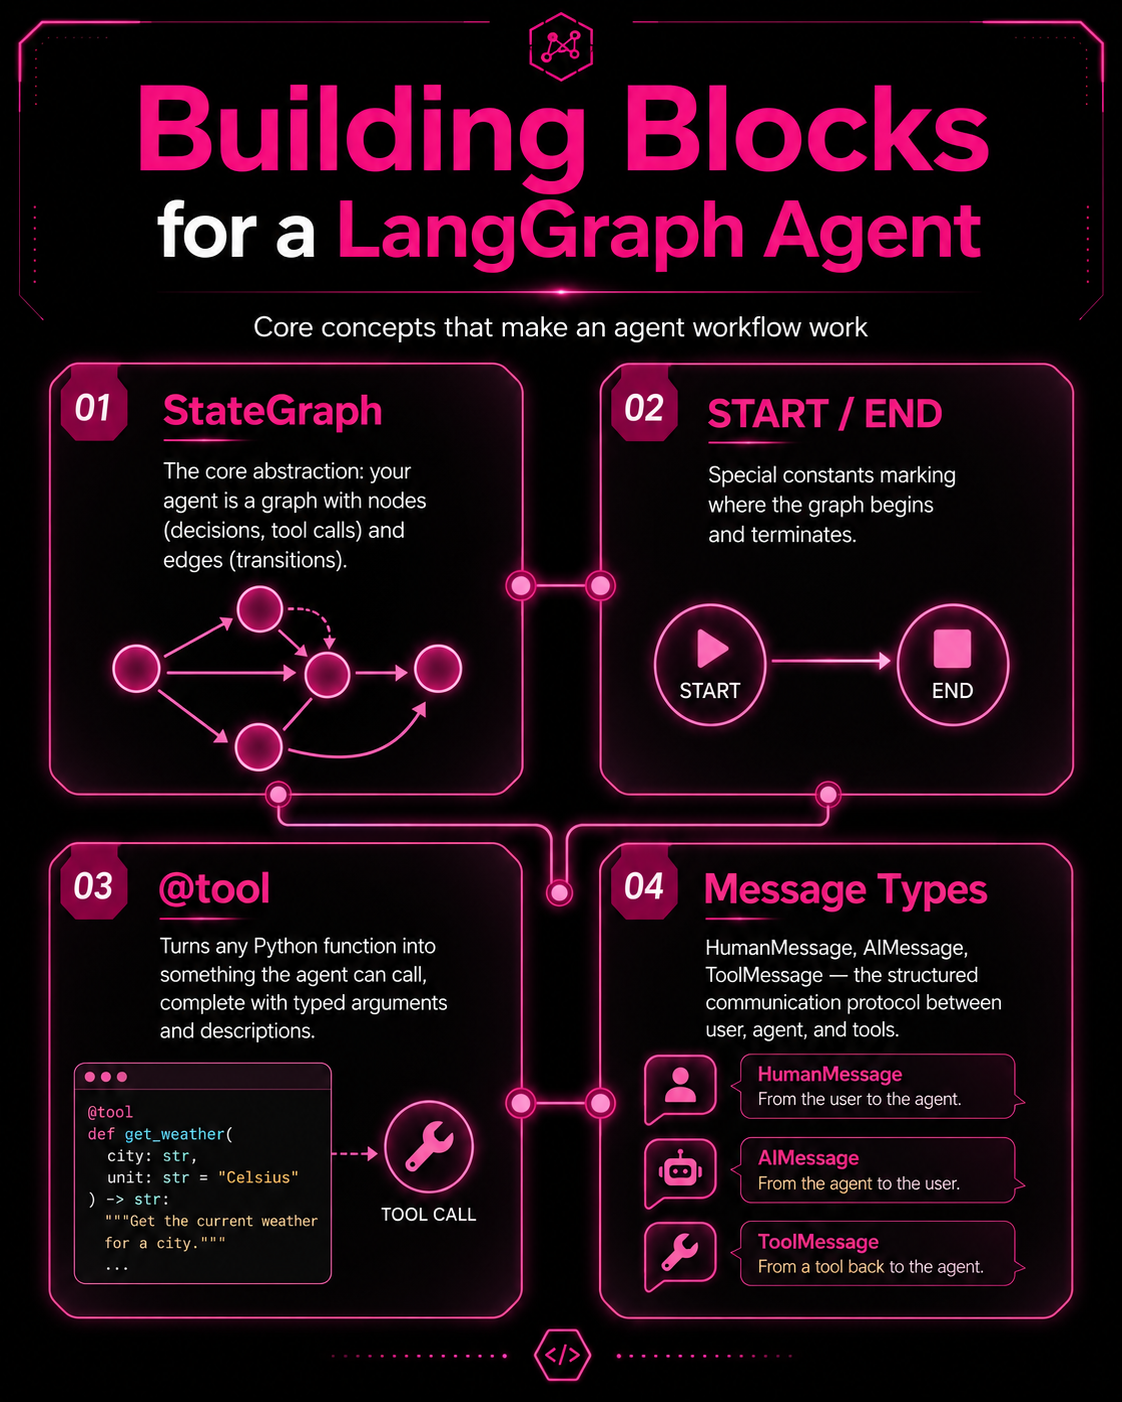

---

## 🛠️ Task 2: Define the Agent's Tools with LangChain

### Goal
Define three travel-related tools using LangChain's `@tool` decorator. These are the functions the agent can call.

### Why `@tool`?
The `@tool` decorator does three important things:
1. **Registers the function** so the agent knows it exists
2. **Extracts the argument schema** from Python type hints (the agent uses this to construct inputs)
3. **Captures the docstring** as the tool description (the agent reads this to decide *when* to use the tool)

In a real system, these tools would call external APIs. Here, they return **simulated responses** so we can focus on evaluation.

### Context: What Each Tool Does

| Tool | When to Use | Returns |
|------|------------|----------|
| `flight_search` | User wants to find or book flights | List of flights with prices, times |
| `hotel_booking` | User wants to book a hotel | Hotel details with price |
| `calendar_check` | User wants to check availability before booking | Conflicts list (may be empty) |

### Steps
Run the cell below to define all three tools. Read through the code — the comments explain what each tool simulates and why.

In [ ]:
# ============================================================
# Tool Definitions — The Agent's Capabilities
# ============================================================
# Each @tool function is something the agent can call.
# The decorator reads the function signature + docstring to create
# a tool schema that the agent uses to decide what to call and how.
#
# IMPORTANT: These are *simulated* tools. They return controlled
# responses so we can test evaluation logic reproducibly.
# In production, you'd replace the body with real API calls.


@tool
def flight_search(origin: str, destination: str, date: str, passengers: int) -> str:
    """Search for available flights between two airports on a given date.

    Args:
        origin: Origin airport code (e.g., 'SFO', 'JFK')
        destination: Destination airport code (e.g., 'LAX', 'LHR')
        date: Travel date in YYYY-MM-DD format
        passengers: Number of passengers (must be >= 1)

    Returns:
        JSON string with flight results or error message
    """
    # --- Input validation (simulates what a real API would check) ---
    if origin == destination:
        return json.dumps({"status": "error", "message": "Origin and destination cannot be the same."})

    try:
        datetime.strptime(date, "%Y-%m-%d")
    except (ValueError, TypeError):
        return json.dumps({"status": "error", "message": f"Invalid date format: '{date}'. Expected YYYY-MM-DD."})

    if not isinstance(passengers, int) or passengers < 1:
        return json.dumps({"status": "error", "message": f"Invalid passengers: {passengers}. Must be integer >= 1."})

    # --- Simulated flight results ---
    # We use a deterministic mapping so results are reproducible across runs.
    # The key insight: the TOOL works correctly. Failures come from the AGENT's
    # decisions about which tool to call, what inputs to pass, and how to
    # interpret the results.
    flights = [
        {"flight": f"FL-{hash((origin, destination, date)) % 900 + 100}",
         "depart": "08:00", "arrive": "11:30", "price": 180 + hash(origin) % 100},
        {"flight": f"FL-{hash((destination, origin, date)) % 900 + 100}",
         "depart": "14:00", "arrive": "17:30", "price": 145 + hash(destination) % 80},
    ]
    return json.dumps({"status": "success", "flights": flights, "currency": "USD"})


@tool
def hotel_booking(city: str, check_in: str, check_out: str, guests: int, budget: float) -> str:
    """Book a hotel room in a city for specified dates.

    Args:
        city: City name for the hotel (e.g., 'London', 'Paris')
        check_in: Check-in date in YYYY-MM-DD format
        check_out: Check-out date in YYYY-MM-DD format (must be after check_in)
        guests: Number of guests (must be >= 1)
        budget: Maximum price per night in USD (must be > 0)

    Returns:
        JSON string with booking confirmation or error message
    """
    # --- Input validation ---
    try:
        ci = datetime.strptime(check_in, "%Y-%m-%d")
        co = datetime.strptime(check_out, "%Y-%m-%d")
        if co <= ci:
            return json.dumps({"status": "error", "message": "Check-out date must be after check-in date."})
    except (ValueError, TypeError):
        return json.dumps({"status": "error", "message": f"Invalid date format. Expected YYYY-MM-DD."})

    if not isinstance(guests, int) or guests < 1:
        return json.dumps({"status": "error", "message": f"Invalid guests: {guests}. Must be integer >= 1."})

    if budget <= 0:
        return json.dumps({"status": "error", "message": f"Invalid budget: {budget}. Must be > 0."})

    # --- Simulate budget-sensitive results ---
    # Paris under $100 returns no results (used to test looping behavior)
    nights = (co - ci).days
    base_price = 90 + hash(city) % 80  # Deterministic per-city pricing

    if budget < base_price:
        return json.dumps({"status": "no_results", "message": f"No hotels in {city} under ${budget}/night."})

    hotel_name = f"{city} Grand Hotel"
    total = base_price * nights
    return json.dumps({
        "status": "success",
        "hotel": hotel_name,
        "price_per_night": base_price,
        "total_price": total,
        "nights": nights
    })


@tool
def calendar_check(user_id: str, date_range_start: str, date_range_end: str) -> str:
    """Check a user's calendar for scheduling conflicts in a date range.

    Args:
        user_id: The user's identifier (e.g., 'user_current')
        date_range_start: Start date in YYYY-MM-DD format
        date_range_end: End date in YYYY-MM-DD format

    Returns:
        JSON string with conflict list (may be empty if user is free)
    """
    try:
        start = datetime.strptime(date_range_start, "%Y-%m-%d")
        end = datetime.strptime(date_range_end, "%Y-%m-%d")
    except (ValueError, TypeError):
        return json.dumps({"status": "error", "message": "Invalid date format. Expected YYYY-MM-DD."})

    # --- Simulated calendar data ---
    # Some dates have conflicts, others are clear. This lets us test
    # whether the agent correctly interprets conflicts vs free time.
    known_conflicts = {
        "2026-03-27": [{"event": "Q1 Review", "time": "14:00-16:00"}],
        "2026-03-23": [
            {"event": "All-hands meeting", "time": "09:00-12:00"},
            {"event": "Lunch with VP", "time": "12:00-13:00"}
        ],
        "2026-03-29": [{"event": "Workshop", "time": "09:00-17:00"}],
    }

    # Check each date in the range for conflicts
    conflicts = []
    current = start
    while current <= end:
        date_str = current.strftime("%Y-%m-%d")
        if date_str in known_conflicts:
            for c in known_conflicts[date_str]:
                conflicts.append({**c, "date": date_str})
        current += timedelta(days=1)

    return json.dumps({"status": "success", "conflicts": conflicts})


# Collect all tools into a list — we'll pass this to the agent graph
ALL_TOOLS = [flight_search, hotel_booking, calendar_check]
TOOL_MAP = {t.name: t for t in ALL_TOOLS}  # name → function lookup

# Display what we defined
print("✅ Three tools defined:\n")
for t in ALL_TOOLS:
    print(f"  📦 {t.name}")
    print(f"     Description: {t.description[:80]}...")
    print(f"     Args: {list(t.args.keys())}")
    print()

✅ Three tools defined:

  📦 flight_search
     Description: Search for available flights between two airports on a given date.

    Args:
  ...
     Args: ['origin', 'destination', 'date', 'passengers']

  📦 hotel_booking
     Description: Book a hotel room in a city for specified dates.

    Args:
        city: City n...
     Args: ['city', 'check_in', 'check_out', 'guests', 'budget']

  📦 calendar_check
     Description: Check a user's calendar for scheduling conflicts in a date range.

    Args:
   ...
     Args: ['user_id', 'date_range_start', 'date_range_end']



### Checkpoint ✅
You should see three tools listed with their names, descriptions, and argument lists.

### 🔍 What Just Happened?
You defined three LangChain tools using the `@tool` decorator. Each tool:
- Has **typed arguments** (the agent knows what inputs to construct)
- Has a **docstring** (the agent reads this to decide when to use the tool)
- Returns **JSON strings** (structured results the agent must parse)
- Includes **input validation** (returns errors for bad inputs — the agent must handle these)

> 💡 **Key Concept:** In LangGraph, tools are *external functions* the agent can invoke. The agent doesn't know how tools work internally — it only sees the name, description, and argument schema. This is why good tool descriptions and typed arguments matter: they're the agent's only guide.

### 🔑 Key Takeaway
**The `@tool` decorator is the contract between agent and function.** The function signature defines what inputs the agent must provide. The docstring tells the agent *when* to call it. If you write vague descriptions or untyped arguments, the agent will make bad calls — and you'll see it in evaluation.

---

## 🏗️ Task 3: Build the Agent Graph with LangGraph

### Goal
Build a LangGraph `StateGraph` that implements the agent's decision loop: receive a request → decide which tool to call → execute the tool → interpret the result → decide again (or finish).

### Why a Graph?
A graph makes the agent's decision process **explicit and inspectable**:

```
        ┌──────────────┐
 START ─▶│   PLANNER    │◀─────────────────────┐
        │  (decide     │                       │
        │   next step) │                       │
        └──────┬───────┘                       │
               │                               │
        ┌──────▼───────┐     ┌──────────────┐  │
        │  Has tool    │ Yes │  TOOL        │  │
        │  call?  ─────┼────▶│  EXECUTOR    │──┘
        │              │     │  (run tool,  │
        └──────┬───────┘     │  return      │
               │ No          │  result)     │
               ▼             └──────────────┘
              END
```

Each box is a **node** in the graph. Each arrow is an **edge**. The conditional routing ("Has tool call?") is what makes agents different from pipelines — the agent decides at runtime which path to take.

### Architecture Decisions
We use a **simulated planner** instead of a real LLM for two reasons:
1. **Reproducibility:** Same input → same output, every time. Essential for evaluation.
2. **Controlled failures:** We can precisely engineer specific failure modes to test our evaluation pipeline.

The planner uses a **scenario lookup table** — given a user request, it returns a pre-scripted sequence of tool calls. This is exactly how you'd test an agent in a CI/CD pipeline.

### Steps
Run the cells below to define the agent state, the scenario data, the planner node, the tool executor node, and compile the graph.

In [ ]:
# ============================================================
# Step 1: Define the Agent State
# ============================================================
# In LangGraph, the "state" is a typed dictionary that flows through
# every node in the graph. Each node reads from the state and writes
# back to it. Think of it as the agent's working memory.


# An agent needs state because the agent is not just answering once — it is moving through a workflow.

# Each step/node needs to remember what happened before.

# Think of state as the agent’s working memory.

# For example, suppose an agent is trying to schedule a meeting.

# The workflow might be:

# User asks: “Can I meet next week?”
# Agent extracts the date range.
# Agent checks the calendar.
# Agent sees conflicts.
# Agent writes the final answer.

# Each step needs information from the previous step.
#
# WHY TypedDict?
# - Type safety: catches bugs at definition time, not at runtime
# - Documentation: anyone reading the code knows exactly what data flows
# - LangGraph requirement: the framework needs to know the state shape

class AgentState(TypedDict):
    """The state that flows through every node in our agent graph."""

    # The original user request (never modified after initial set)
    user_request: str

    # Which scenario is being executed (maps to our test data)
    scenario_id: str

    # The planned sequence of tool calls the agent will make
    # Each entry: {"tool": str, "args": dict, "reasoning": str}
    planned_actions: list

    # Index tracking which planned action we're currently on
    current_step: int

    # Complete trace of everything that happened (our evaluation goldmine)
    # Each entry: {"step": int, "tool": str, "inputs": dict,
    #              "output": dict, "reasoning": str, "timestamp": str}
    trace: list

    # The agent's pending tool call (set by planner, consumed by executor)
    # None when there's nothing to execute
    pending_tool_call: dict

    # The agent's final answer to the user (set when done)
    final_answer: str

    # Whether the agent has finished processing
    is_done: bool


print("✅ AgentState defined with fields:")
for field_name, field_type in AgentState.__annotations__.items():
    print(f"   • {field_name}: {field_type}")

✅ AgentState defined with fields:
   • user_request: <class 'str'>
   • scenario_id: <class 'str'>
   • planned_actions: <class 'list'>
   • current_step: <class 'int'>
   • trace: <class 'list'>
   • pending_tool_call: <class 'dict'>
   • final_answer: <class 'str'>
   • is_done: <class 'bool'>


# Why Use Deterministic Test Cases for Agent Evaluation?

When building an AI agent, a real LLM may behave differently each time. That is useful later, but it makes early testing hard.

To test the evaluation system, we often replace the real LLM with a **simulated LLM** that follows scripted actions.

## The Main Idea

A simulated LLM does not prove how GPT-4 or another model will behave.

Instead, it helps answer this question:

> Can our agent system and evaluator correctly detect known good and bad behavior?

## Why Simulate?

Real LLM behavior can vary across runs. The same prompt might produce:

* the correct tool call
* the wrong tool call
* no tool call
* a correct answer with a bad process
* a loop or repeated action

That makes debugging difficult. If the test fails, it is unclear whether the problem is the LLM or the evaluation code.

A deterministic test removes that uncertainty.

## Example

Suppose an agent should check a calendar before answering.

A good path might be:

```text
extract_dates → calendar_check → final_answer
```

A bad path might be:

```text
extract_dates → weather_check → final_answer
```

With a scripted scenario, we can force the bad behavior and verify that the evaluator catches it.

Expected evaluator result:

```text
Failed: expected calendar_check, but agent called weather_check.
```

If the evaluator does not catch this, then the evaluator needs to be fixed.

## What Deterministic Tests Are Really Testing

They test the surrounding system:

* Does the graph run correctly?
* Is state updated correctly?
* Are tool calls logged correctly?
* Does the evaluator detect wrong tools?
* Does it detect loops?
* Does it detect skipped steps?
* Does it correctly pass successful cases?

They are not mainly testing the intelligence of the LLM.

## Two Types of Testing

Use both:

```text
1. Simulated LLM tests
   Purpose: Test the agent framework and evaluation logic.

2. Real LLM tests
   Purpose: Test actual model behavior in realistic conditions.
```

## Key Takeaway

Deterministic scenarios are like controlled lab tests.

Real LLM tests are like field tests.

A strong agent evaluation setup uses deterministic tests first to verify the pipeline, then real LLM tests to evaluate actual agent behavior.


You force bad behavior **on purpose during testing** for the same reason you test that a smoke alarm goes off when there is smoke.

You are not saying:

> “We want the real agent to behave badly.”

You are saying:

> “If the real agent ever behaves badly, will our evaluation system notice?”

## Why force bad behavior?

Because you need to prove your evaluator can catch mistakes.

For example, suppose your agent is supposed to answer this:

```text
Can I meet next week?
```

A good agent should probably call:

```text
calendar_check
```

But a bad agent might accidentally call:

```text
weather_check
```

So in a test, you intentionally script this wrong behavior:

```text
User asks about meeting availability
Agent calls weather_check
Agent gives final answer
```

Now you check:

> Did our evaluator catch that the wrong tool was used?

If yes, good. Your evaluator works.

If no, your evaluator is too weak.

---

## What is the evaluator?

The **evaluator** is the code or logic that checks whether the agent behaved correctly.

It is not necessarily another LLM. It can be simple Python code.

For example, an evaluator might inspect the agent’s trace:

```python
trace = [
    {"step": 1, "tool": "extract_dates"},
    {"step": 2, "tool": "weather_check"},
    {"step": 3, "tool": "final_answer"}
]
```

Then it checks:

```python
required_tool = "calendar_check"

tools_used = [step["tool"] for step in trace]

if required_tool not in tools_used:
    print("Failed: expected calendar_check, but agent did not call it.")
```

So the evaluator is basically asking:

```text
Did the agent do the required steps?
Did it use the right tools?
Did it avoid bad patterns?
Did it produce a correct final answer?
```

---

## Simple analogy

Imagine testing a calculator app.

You might intentionally give it a case like:

```text
2 + 2
```

Expected answer:

```text
4
```

If it returns `5`, your test should fail.

But you also want to test whether your testing system catches errors. So you may intentionally simulate:

```text
Calculator returns 5
```

Then your evaluator should say:

```text
Fail: expected 4, got 5
```

Same idea with agents.

---

## Agent example

A scheduling agent may have rules like:

```text
For meeting availability questions:
1. Extract the date range.
2. Call calendar_check.
3. Use the calendar results in the final answer.
```

The evaluator checks the actual path:

```text
extract_dates → weather_check → final_answer
```

Against the expected path:

```text
extract_dates → calendar_check → final_answer
```

So it flags:

```text
Failed: expected calendar_check, but agent called weather_check.
```

---

## Key takeaway

You force bad behavior only in the **test scenario**, not in the real agent.

The purpose is to verify that your evaluator can detect known failure patterns before you trust it on unpredictable real LLM behavior.

In this context:

```text
Simulated bad behavior = controlled test case
Evaluator = the scoring/checking logic that judges the agent’s behavior
Agent trace = the record of what the agent actually did
```


In [ ]:
# ============================================================
# Step 2: Define Test Scenarios
# ============================================================
# Each scenario defines what the agent WILL DO for a given request.
# This is our "simulated LLM" — instead of calling GPT-4, the planner
# looks up the scenario and follows the pre-scripted actions.
#
# WHY SIMULATE?
# In evaluation, you need REPRODUCIBLE behavior. If you call a real LLM,
# you get different results each time, making it impossible to verify
# that your evaluation code works correctly. Simulated scenarios give
# you deterministic, controllable test cases.
#
# Each scenario intentionally exhibits a SPECIFIC behavior pattern
# (success, wrong tools, looping, etc.) so we can test whether our
# evaluation pipeline catches each type of issue.

SCENARIOS = {
    # ── Scenario 1: PERFECT EXECUTION ──────────────────────────
    # The gold standard. Right tools, right order, right inputs.
    # Our evaluation should score this highly on every dimension.
    "T-001": {
        "user_request": "Book me a flight from NYC to London on March 15 and a hotel for 3 nights.",
        "actions": [
            {
                "tool": "flight_search",
                "args": {"origin": "JFK", "destination": "LHR", "date": "2026-03-15", "passengers": 1},
                "reasoning": "User wants a flight from NYC to London. Using JFK and LHR airport codes."
            },
            {
                "tool": "hotel_booking",
                "args": {"city": "London", "check_in": "2026-03-15", "check_out": "2026-03-18", "guests": 1, "budget": 200.0},
                "reasoning": "User needs a hotel in London for 3 nights starting March 15."
            }
        ],
        "final_answer": "I found flights from NYC to London on March 15 and booked a hotel for 3 nights.",
        "ground_truth_tools": ["flight_search", "hotel_booking"],
        "ground_truth_outcome": "Flight booked NYC→London March 15, hotel booked 3 nights in London",
        "expected_status": "success"
    },

    # ── Scenario 2: WRONG TOOL SELECTION ───────────────────────
    # User asks to check calendar, but agent calls flight_search instead.
    # Classic tool selection failure. Should score 0 on tool accuracy.
    "T-002": {
        "user_request": "Check if I'm free next Tuesday afternoon for a client meeting.",
        "actions": [
            {
                "tool": "flight_search",
                "args": {"origin": "NYC", "destination": "NYC", "date": "2026-03-17", "passengers": 1},
                "reasoning": "Checking availability by searching for flights on Tuesday."
            },
            {
                "tool": "hotel_booking",
                "args": {"city": "NYC", "check_in": "2026-03-17", "check_out": "2026-03-17", "guests": 1, "budget": 100.0},
                "reasoning": "Maybe user needs a meeting room. Trying hotel booking."
            }
        ],
        "final_answer": "I wasn't able to find availability for Tuesday. Please try again later.",
        "ground_truth_tools": ["calendar_check"],
        "ground_truth_outcome": "Calendar shows free 2-5 PM on Tuesday March 17",
        "expected_status": "failure"
    },

    # ── Scenario 3: BAD INPUT FORMATTING (with self-correction) ──
    # Agent picks the right tool but botches the input format.
    # Then retries with corrected inputs. Tests error recovery.
    "T-003": {
        "user_request": "Find flights from San Francisco to Tokyo on April 5th for 2 people.",
        "actions": [
            {
                "tool": "flight_search",
                "args": {"origin": "San Francisco", "destination": "Tokyo", "date": "April 5", "passengers": 2},
                "reasoning": "Searching for flights from SF to Tokyo for 2 passengers."
            },
            {
                "tool": "flight_search",
                "args": {"origin": "SFO", "destination": "TYO", "date": "2026-04-05", "passengers": 2},
                "reasoning": "Retrying with corrected airport codes and date format."
            }
        ],
        "final_answer": "Found flights from SFO to Tokyo on April 5 for 2 passengers.",
        "ground_truth_tools": ["flight_search"],
        "ground_truth_outcome": "Flights found SFO→Tokyo April 5 for 2 passengers",
        "expected_status": "partial"
    },

    # ── Scenario 4: LOOPING BEHAVIOR ──────────────────────────
    # Agent calls the same tool with identical inputs 5 times.
    # This is the classic looping failure — no adaptation, no progress.
    "T-004": {
        "user_request": "Find me a hotel in Paris under $50 per night for next weekend.",
        "actions": [
            {"tool": "hotel_booking", "args": {"city": "Paris", "check_in": "2026-03-21", "check_out": "2026-03-23", "guests": 1, "budget": 50.0}, "reasoning": "Searching for budget hotels in Paris."},
            {"tool": "hotel_booking", "args": {"city": "Paris", "check_in": "2026-03-21", "check_out": "2026-03-23", "guests": 1, "budget": 50.0}, "reasoning": "No results. Trying again."},
            {"tool": "hotel_booking", "args": {"city": "Paris", "check_in": "2026-03-21", "check_out": "2026-03-23", "guests": 1, "budget": 50.0}, "reasoning": "Still no results. Trying once more."},
            {"tool": "hotel_booking", "args": {"city": "Paris", "check_in": "2026-03-21", "check_out": "2026-03-23", "guests": 1, "budget": 50.0}, "reasoning": "Retrying the search."},
            {"tool": "hotel_booking", "args": {"city": "Paris", "check_in": "2026-03-21", "check_out": "2026-03-23", "guests": 1, "budget": 50.0}, "reasoning": "One more attempt."}
        ],
        "final_answer": "I was unable to find hotels in Paris under $50/night for next weekend.",
        "ground_truth_tools": ["hotel_booking"],
        "ground_truth_outcome": "Inform user no hotels available under budget; suggest increasing budget or alternate dates",
        "expected_status": "failure"
    },

    # ── Scenario 5: BAD PATH, GOOD OUTCOME (the \"lucky\" agent) ──
    # Agent books hotel BEFORE checking calendar or flights.
    # Outcome looks correct, but the path is dangerous.
    "T-005": {
        "user_request": "I need to fly from Boston to Chicago tomorrow and check my calendar for conflicts.",
        "actions": [
            {
                "tool": "hotel_booking",
                "args": {"city": "Chicago", "check_in": "2026-03-23", "check_out": "2026-03-24", "guests": 1, "budget": 150.0},
                "reasoning": "User is traveling, so they probably need a hotel."
            },
            {
                "tool": "flight_search",
                "args": {"origin": "BOS", "destination": "ORD", "date": "2026-03-23", "passengers": 1},
                "reasoning": "Now searching for the flight the user asked about."
            },
            {
                "tool": "calendar_check",
                "args": {"user_id": "user_current", "date_range_start": "2026-03-23", "date_range_end": "2026-03-24"},
                "reasoning": "User also asked to check calendar."
            }
        ],
        "final_answer": "Found flights from Boston to Chicago tomorrow. I also booked a hotel and checked your calendar — no major conflicts.",
        "ground_truth_tools": ["calendar_check", "flight_search"],
        "ground_truth_outcome": "Check calendar first, then find flights avoiding conflicts",
        "expected_status": "success"
    },

    # ── Scenario 6: OUTPUT MISINTERPRETATION ──────────────────
    # Agent calls the right tool, gets the right output, but
    # MISREADS it. Calendar shows Q1 Review conflict, agent says \"free\".
    # This is the most dangerous failure type — confidently wrong.
    "T-006": {
        "user_request": "Am I free all day Friday? If so, book a flight to Miami.",
        "actions": [
            {
                "tool": "calendar_check",
                "args": {"user_id": "user_current", "date_range_start": "2026-03-27", "date_range_end": "2026-03-27"},
                "reasoning": "Checking if user is free on Friday."
            },
            {
                "tool": "flight_search",
                "args": {"origin": "NYC", "destination": "MIA", "date": "2026-03-27", "passengers": 1},
                "reasoning": "User is free on Friday, searching for Miami flights."
            }
        ],
        "final_answer": "You're free all day Friday! I found flights to Miami. The cheapest departs at 2 PM.",
        "ground_truth_tools": ["calendar_check"],
        "ground_truth_outcome": "User is NOT free all day Friday — has Q1 Review 2-4 PM. Should inform user of conflict.",
        "expected_status": "failure"
    },

    # ── Scenario 7: CLEAN CONDITIONAL EXECUTION ───────────────
    # Calendar first, then flight (conditional). Perfect execution.
    "T-007": {
        "user_request": "Check my calendar for April 10-12 and book a flight from Denver to Seattle if I'm clear.",
        "actions": [
            {
                "tool": "calendar_check",
                "args": {"user_id": "user_current", "date_range_start": "2026-04-10", "date_range_end": "2026-04-12"},
                "reasoning": "Checking calendar first since flight booking is conditional on availability."
            },
            {
                "tool": "flight_search",
                "args": {"origin": "DEN", "destination": "SEA", "date": "2026-04-10", "passengers": 1},
                "reasoning": "Calendar is clear. Proceeding with flight search."
            }
        ],
        "final_answer": "Your calendar is clear April 10-12. I found flights from Denver to Seattle on April 10.",
        "ground_truth_tools": ["calendar_check", "flight_search"],
        "ground_truth_outcome": "Calendar clear, flights found Denver→Seattle April 10",
        "expected_status": "success"
    },

    # ── Scenario 8: UNNECESSARY TOOL CALLS ────────────────────
    # User only asked for a hotel, but agent also checks calendar
    # and searches flights. Extra (unrequested) work.
    "T-008": {
        "user_request": "I need a hotel in Berlin for March 28-30.",
        "actions": [
            {
                "tool": "calendar_check",
                "args": {"user_id": "user_current", "date_range_start": "2026-03-28", "date_range_end": "2026-03-30"},
                "reasoning": "Checking calendar availability for those dates."
            },
            {
                "tool": "flight_search",
                "args": {"origin": "NYC", "destination": "BER", "date": "2026-03-28", "passengers": 1},
                "reasoning": "User needs to get to Berlin somehow."
            },
            {
                "tool": "hotel_booking",
                "args": {"city": "Berlin", "check_in": "2026-03-28", "check_out": "2026-03-30", "guests": 1, "budget": 150.0},
                "reasoning": "Now booking the hotel the user actually asked for."
            }
        ],
        "final_answer": "I booked a hotel in Berlin for March 28-30. Also checked your calendar (workshop on the 29th) and found flights.",
        "ground_truth_tools": ["hotel_booking"],
        "ground_truth_outcome": "Hotel booked in Berlin March 28-30",
        "expected_status": "partial"
    },

    # ── Scenario 9: REVERSED DATES (with self-correction) ─────
    # Agent swaps check-in and check-out, gets an error, then fixes it.
    "T-009": {
        "user_request": "Book a hotel in Tokyo from March 25 to March 30.",
        "actions": [
            {
                "tool": "hotel_booking",
                "args": {"city": "Tokyo", "check_in": "2026-03-30", "check_out": "2026-03-25", "guests": 1, "budget": 200.0},
                "reasoning": "Booking hotel in Tokyo for these dates."
            },
            {
                "tool": "hotel_booking",
                "args": {"city": "Tokyo", "check_in": "2026-03-25", "check_out": "2026-03-30", "guests": 1, "budget": 200.0},
                "reasoning": "Error — dates were reversed. Correcting to March 25 check-in, March 30 check-out."
            }
        ],
        "final_answer": "I booked a hotel in Tokyo from March 25-30.",
        "ground_truth_tools": ["hotel_booking"],
        "ground_truth_outcome": "Should clarify dates with user before assuming correction; booked March 25-30",
        "expected_status": "partial"
    },

    # ── Scenario 10: PREMATURE TERMINATION ────────────────────
    # User asks for 3 things, agent only does 1 and stops.
    "T-010": {
        "user_request": "Plan my trip: fly from LA to NYC on April 1, hotel for 4 nights, and check my calendar.",
        "actions": [
            {
                "tool": "flight_search",
                "args": {"origin": "LAX", "destination": "JFK", "date": "2026-04-01", "passengers": 1},
                "reasoning": "Searching for flights from LA to NYC."
            }
        ],
        "final_answer": "I found flights from LA to NYC on April 1.",
        "ground_truth_tools": ["calendar_check", "flight_search", "hotel_booking"],
        "ground_truth_outcome": "Check calendar, book flight LA→NYC April 1, book hotel 4 nights in NYC",
        "expected_status": "failure"
    }
}

print(f"✅ Defined {len(SCENARIOS)} test scenarios:\n")
for sid, s in SCENARIOS.items():
    n_actions = len(s['actions'])
    tools_seq = ' → '.join(a['tool'] for a in s['actions'])
    print(f"  {sid}: \"{s['user_request'][:55]}...\"")
    print(f"        Steps: {n_actions} | Tools: {tools_seq} | Expected: {s['expected_status']}")
    print()

✅ Defined 10 test scenarios:

  T-001: "Book me a flight from NYC to London on March 15 and a h..."
        Steps: 2 | Tools: flight_search → hotel_booking | Expected: success

  T-002: "Check if I'm free next Tuesday afternoon for a client m..."
        Steps: 2 | Tools: flight_search → hotel_booking | Expected: failure

  T-003: "Find flights from San Francisco to Tokyo on April 5th f..."
        Steps: 2 | Tools: flight_search → flight_search | Expected: partial

  T-004: "Find me a hotel in Paris under $50 per night for next w..."
        Steps: 5 | Tools: hotel_booking → hotel_booking → hotel_booking → hotel_booking → hotel_booking | Expected: failure

  T-005: "I need to fly from Boston to Chicago tomorrow and check..."
        Steps: 3 | Tools: hotel_booking → flight_search → calendar_check | Expected: success

  T-006: "Am I free all day Friday? If so, book a flight to Miami..."
        Steps: 2 | Tools: calendar_check → flight_search | Expected: failure

  T-007: "Check my cal

In [ ]:
# ============================================================
# Step 3: Define the Graph Nodes
# ============================================================
# A LangGraph node is a function that takes the current state,
# does some work, and returns updates to the state.
#
# Our agent has two nodes:
# 1. PLANNER: Decides which tool to call next (or to finish)
# 2. TOOL_EXECUTOR: Actually runs the tool and records the result

# These are graph nodes, but in this code they are only defined, not fully connected yet.

# This section creates the functions that will become nodes in the LangGraph workflow. The actual connection usually happens later with code like:

def planner_node(state: AgentState) -> dict:
    """
    The agent's 'brain' — decides the next action.

    In a real agent, this would call an LLM (e.g., GPT-4, Claude) to decide
    the next tool call based on the conversation so far. Here, we use our
    scenario lookup table for reproducibility.

    The planner either:
    - Sets pending_tool_call (there's more work to do)
    - Sets is_done=True (we're finished)
    """
    step_idx = state["current_step"]
    actions = state["planned_actions"]

    if step_idx < len(actions):
        # There are more actions to execute
        action = actions[step_idx]
        return {
            "pending_tool_call": {
                "tool": action["tool"],
                "args": action["args"],
                "reasoning": action["reasoning"]
            },
            "is_done": False
        }
    else:
        # All actions completed — produce final answer
        scenario = SCENARIOS.get(state["scenario_id"], {})
        return {
            "pending_tool_call": None,
            "is_done": True,
            "final_answer": scenario.get("final_answer", "Task complete.")
        }


def tool_executor_node(state: AgentState) -> dict:
    """
    Executes the pending tool call and records the result in the trace.

    This is analogous to LangGraph's built-in ToolNode, but we add
    custom tracing so we can evaluate every detail of the execution.

    In production, you'd use LangGraph's ToolNode + Langfuse for tracing.
    Here we do it manually to make the evaluation data structure explicit.
    """
    tool_call = state["pending_tool_call"]
    if tool_call is None:
        return {}  # Nothing to execute

    tool_name = tool_call["tool"]
    tool_args = tool_call["args"]

    # --- Execute the actual tool ---
    tool_fn = TOOL_MAP.get(tool_name)
    if tool_fn:
        try:
            result_str = tool_fn.invoke(tool_args)
            result = json.loads(result_str)
        except Exception as e:
            result = {"status": "error", "message": str(e)}
    else:
        result = {"status": "error", "message": f"Unknown tool: {tool_name}"}

    # --- Record in trace (the evaluation data we'll analyze later) ---
    step_num = state["current_step"] + 1
    trace_entry = {
        "step": step_num,
        "tool": tool_name,
        "inputs": tool_args,
        "output": result,
        "reasoning": tool_call["reasoning"],
        "timestamp": datetime.now().isoformat()
    }

    # Build new trace list (LangGraph state is immutable, so we create a new list)
    new_trace = list(state["trace"]) + [trace_entry]

    return {
        "trace": new_trace,
        "current_step": step_num,  # Advance to next action
        "pending_tool_call": None   # Clear the pending call
    }


def should_continue(state: AgentState) -> str:
    """
    Conditional edge function: decides whether the agent loops back
    to the planner or terminates.

    This is the 'routing' logic in the graph — it checks the state
    and returns the name of the next node to visit.

    Returns:
        'tool_executor' if there's a pending tool call
        '__end__' if the agent is done
    """
    if state.get("is_done", False):
        return END
    if state.get("pending_tool_call") is not None:
        return "tool_executor"
    return END


print("✅ Graph nodes defined:")
print("   • planner_node: Decides the next tool call (or finishes)")
print("   • tool_executor_node: Runs the tool and records the trace")
print("   • should_continue: Routes between executor and end")

✅ Graph nodes defined:
   • planner_node: Decides the next tool call (or finishes)
   • tool_executor_node: Runs the tool and records the trace
   • should_continue: Routes between executor and end


# LangGraph Nodes: Planner, Tool Executor, and Router

Explaining the code above...

In LangGraph, a **node** is a function that receives the current state, does one job, and returns updates to the state.

This example defines three important pieces of an agent workflow:

```text
planner_node → tool_executor_node → planner_node → ...
```

The agent keeps looping until the task is done.

## 1. `planner_node`: Decides What to Do Next

The planner is the agent’s decision-maker.

It looks at:

```python
state["current_step"]
state["planned_actions"]
```

Then it decides whether there is another action to run.

If there is another action, it creates a `pending_tool_call`:

```python
{
    "tool": "calendar_check",
    "args": {...},
    "reasoning": "Need to check calendar availability."
}
```

The planner does **not** run the tool. It only decides which tool should be called next.

If there are no more actions, it marks the task as done:

```python
"is_done": True
```

and produces the final answer.

## 2. `tool_executor_node`: Runs the Tool

The tool executor looks for:

```python
state["pending_tool_call"]
```

If a pending tool call exists, it:

1. Gets the tool name
2. Gets the tool arguments
3. Looks up the tool in `TOOL_MAP`
4. Runs the tool
5. Records the result

Example:

```text
Planner says: call calendar_check
Executor does: runs calendar_check with the given inputs
```

## 3. Trace: Records What Happened

After running the tool, the executor creates a trace entry.

The trace records:

* step number
* tool used
* inputs sent to the tool
* output returned by the tool
* reasoning
* timestamp

This trace is useful for evaluation because it shows exactly what the agent did.

Example:

```text
Step 1:
Tool: calendar_check
Inputs: March 23 to March 29
Output: conflicts found
Reasoning: Need to check calendar availability
```

## 4. `should_continue`: Routes the Graph

`should_continue` decides where the graph goes next.

It checks the state:

```text
If is_done is True → stop
If pending_tool_call exists → go to tool_executor
Otherwise → stop
```

This is the routing logic that controls the loop.

## Are the Nodes Connected?

In this code block, the nodes are only **defined**.

They become connected later when the graph is built with code such as:

```python
graph.add_node("planner", planner_node)
graph.add_node("tool_executor", tool_executor_node)
graph.add_edge("tool_executor", "planner")
graph.add_conditional_edges("planner", should_continue)
```

## Key Takeaway

This code defines a basic tool-using agent loop:

```text
Planner: decides the next action
Executor: runs the selected tool
Trace: records what happened
Router: decides whether to continue or stop
```

The planner chooses.
The executor acts.
The trace records.
The router controls the flow.


In [ ]:
# ============================================================
# Step 4: Build and Compile the Agent Graph
# ============================================================
# Now we wire everything together into a LangGraph StateGraph.
# This is the actual agent architecture.
#
# The graph structure:
#   START → planner → (conditional) → tool_executor → planner → ... → END
#
# The planner and tool_executor alternate until the planner
# sets is_done=True, at which point should_continue routes to END.

def build_agent_graph():
    """Build and compile the LangGraph agent."""

    # Create a new graph with our state type
    graph = StateGraph(AgentState)

    # Add nodes (the two functions we defined above)
    graph.add_node("planner", planner_node)
    graph.add_node("tool_executor", tool_executor_node)

    # Add edges (how nodes connect to each other)
    # START → planner: The agent always begins by planning
    graph.add_edge(START, "planner")

    # planner → (conditional): After planning, either execute a tool or finish
    graph.add_conditional_edges(
        "planner",
        should_continue,
        {
            "tool_executor": "tool_executor",  # If there's a tool to call
            END: END                              # If we're done
        }
    )

    # tool_executor → planner: After executing a tool, go back to plan next step
    graph.add_edge("tool_executor", "planner")

    # Compile the graph — this validates the structure and makes it executable
    return graph.compile()


# Build it!
agent = build_agent_graph()

print("✅ Agent graph compiled successfully!")
print()
print("   Graph structure:")
print("   START → planner → [conditional] → tool_executor → planner → ... → END")
print()
print("   This is the ReAct pattern implemented as a graph:")
print("   Plan (reason) → Act (execute tool) → Observe (read result) → Plan again")

✅ Agent graph compiled successfully!

   Graph structure:
   START → planner → [conditional] → tool_executor → planner → ... → END

   This is the ReAct pattern implemented as a graph:
   Plan (reason) → Act (execute tool) → Observe (read result) → Plan again


### Checkpoint ✅
You should see `✅ Agent graph compiled successfully!`

### 🔍 What Just Happened?
You built a complete LangGraph agent with:
- **State management** (`AgentState`) — the agent's working memory that flows through every step
- **Planner node** — decides which tool to call next (simulated LLM)
- **Tool executor node** — runs the actual tool and records the trace
- **Conditional routing** — the graph dynamically decides whether to loop or finish

This is the **same architecture** used by production LangGraph agents. The only difference is that production agents use a real LLM in the planner node instead of our scenario lookup table.

> 💡 **Key Insight:** The graph makes the agent's decision process *visible*. Instead of a black-box LLM call, you can see exactly: (1) what the planner decided, (2) what tool was called, (3) what the tool returned, (4) what the planner decided next. This visibility is what makes evaluation possible.

### 🔑 Key Takeaway
**Agents are loops, not pipelines.** A pipeline runs once: input → process → output. An agent *loops*: plan → act → observe → plan again. The `StateGraph` makes this loop explicit. Every time the planner runs, it's a decision point you can evaluate. Every time the tool executor runs, it's an action you can audit. This is the foundation of agent evaluation: if you can't see the loop, you can't evaluate it.

---

## 🏃 Task 4: Run the Agent and Capture Traces

### Goal
Execute the agent against all 10 test scenarios and capture the full execution trace for each one. The traces are the raw data we'll evaluate in the rest of the lab.

### What Happens When You Run the Agent
For each scenario, the LangGraph runtime:
1. Initializes the state with the user request and planned actions
2. Calls the planner node → sets the next tool call
3. Routes to the tool executor → runs the tool, records the trace
4. Routes back to the planner → repeats until done
5. Returns the final state with the complete trace

### Steps
Run the cell below to execute all scenarios and collect traces.

In [ ]:
# ============================================================
# Run All Scenarios Through the LangGraph Agent
# ============================================================
# We invoke the compiled graph for each scenario, capturing the
# complete state (including trace) after execution.
#
# The trace is our evaluation goldmine — it records every tool call,
# every input, every output, and the reasoning behind each decision.

def run_scenario(agent_graph, scenario_id: str) -> dict:
    """
    Run a single scenario through the LangGraph agent.

    Returns the complete final state, including:
    - trace: list of every tool call with inputs/outputs
    - final_answer: the agent's response to the user
    - All scenario metadata for evaluation
    """
    scenario = SCENARIOS[scenario_id]

    # Build the initial state — this is what the agent starts with
    initial_state = {
        "user_request": scenario["user_request"],
        "scenario_id": scenario_id,
        "planned_actions": scenario["actions"],
        "current_step": 0,
        "trace": [],
        "pending_tool_call": None,
        "final_answer": "",
        "is_done": False
    }

    # Invoke the graph — LangGraph handles all the routing automatically
    final_state = agent_graph.invoke(initial_state)

    # Attach ground truth for evaluation
    final_state["ground_truth_tools"] = scenario["ground_truth_tools"]
    final_state["ground_truth_outcome"] = scenario["ground_truth_outcome"]
    final_state["expected_status"] = scenario["expected_status"]

    return final_state


# Run all scenarios and collect results
print("=" * 70)
print("RUNNING ALL SCENARIOS THROUGH LANGGRAPH AGENT")
print("=" * 70)

all_results = {}
for scenario_id in SCENARIOS:
    result = run_scenario(agent, scenario_id)
    all_results[scenario_id] = result

    n_steps = len(result["trace"])
    tools = [t["tool"] for t in result["trace"]]
    print(f"\n  {scenario_id}: {n_steps} steps | {' → '.join(tools)}")
    print(f"    Request: \"{result['user_request'][:55]}...\"")
    print(f"    Answer:  \"{result['final_answer'][:55]}...\"")

    # Show trace summary
    for t in result["trace"]:
        status = t["output"].get("status", "unknown")
        icon = "✅" if status == "success" else ("⚠️" if status == "no_results" else "❌")
        print(f"    Step {t['step']}: {t['tool']} → {icon} {status}")

# Summary
total_steps = sum(len(r["trace"]) for r in all_results.values())
print(f"\n{'=' * 70}")
print(f"SUMMARY: {len(all_results)} scenarios, {total_steps} total tool calls")

RUNNING ALL SCENARIOS THROUGH LANGGRAPH AGENT

  T-001: 2 steps | flight_search → hotel_booking
    Request: "Book me a flight from NYC to London on March 15 and a h..."
    Answer:  "I found flights from NYC to London on March 15 and book..."
    Step 1: flight_search → ✅ success
    Step 2: hotel_booking → ✅ success

  T-002: 2 steps | flight_search → hotel_booking
    Request: "Check if I'm free next Tuesday afternoon for a client m..."
    Answer:  "I wasn't able to find availability for Tuesday. Please ..."
    Step 1: flight_search → ❌ error
    Step 2: hotel_booking → ❌ error

  T-003: 2 steps | flight_search → flight_search
    Request: "Find flights from San Francisco to Tokyo on April 5th f..."
    Answer:  "Found flights from SFO to Tokyo on April 5 for 2 passen..."
    Step 1: flight_search → ❌ error
    Step 2: flight_search → ✅ success

  T-004: 5 steps | hotel_booking → hotel_booking → hotel_booking → hotel_booking → hotel_booking
    Request: "Find me a hotel in Paris u

### Checkpoint ✅
You should see 10 scenarios executed with varying numbers of steps and outcomes. Verify:
- **T-001, T-007**: Clean runs, all steps succeed (✅✅)
- **T-002**: Both steps fail (wrong tools for the task)
- **T-004**: 5 steps, all returning `no_results` (looping!)
- **T-006**: Steps succeed but the agent misinterprets the calendar (the sneaky one)

### 🔍 What Just Happened?
You ran a real LangGraph agent (with simulated decisions) and captured **execution traces** — structured records of every decision and tool call. These traces are the foundation for all evaluation that follows.

Notice the *variety* of behaviors across just 10 scenarios: perfect execution, wrong tools, invalid inputs, looping, misinterpretation, premature termination. Real agents exhibit all of these in production. The difference is that here, you can see them clearly because the test cases are designed to surface each pattern.

> 💡 **Production Context:** In deployment, you'd capture these traces using [Langfuse](https://langfuse.com/) (open-source), [LangSmith](https://smith.langchain.com/), or another observability tool. The trace structure is identical — tool calls, inputs, outputs, timestamps. Our manual tracing here teaches you what to look for.

### 🔑 Key Takeaway
**Traces are the raw material of agent evaluation.** Without traces, you're evaluating a black box ("did the user get a good answer?"). With traces, you can perform forensic analysis ("the agent called the wrong tool at step 2, passed invalid inputs at step 3, and ignored a calendar conflict at step 4"). Every evaluation technique in this lab depends on trace data.

---

## 🧠 Task 5: Think First — Predicting Failure Modes

### Goal
Before writing evaluation code, reason about what can go wrong. This builds the mental model you need to design effective evaluations.

### Why Think First?
It's tempting to jump straight to writing evaluation code. But the best evaluators are the ones who *predict* failures before measuring them. If you can anticipate how an agent will fail, you can design evaluations that specifically target those failure modes instead of testing blindly.

### Context
You saw the agent execute 10 scenarios above. Some succeeded, some failed, some partially worked. Now think about *why* — where in the decision chain did things break down?

```
Where Agents Fail: The Decision Chain
═══════════════════════════════════════════

 User Request ─────────────────────▶ Final Answer
      │                                    ▲
      │  ❌ Wrong tool selected (T-002)    │
      │  ❌ Wrong tool order (T-005)       │
      ▼                                    │
   Tool Call ──────────────────────▶ Output
      │                                    ▲
      │  ❌ Bad input format (T-003)       │
      │  ❌ Invalid input values (T-009)   │
      ▼                                    │
   Execution ──────────────────────▶ Result
      │                                    ▲
      │  ❌ Looping / no progress (T-004)  │
      │  ❌ Premature termination (T-010)  │
      │  ❌ Output misinterpretation (T-006)│
      └────────────────────────────────────┘
```

Each failure type happens at a different point in the chain — and requires a *different* evaluation technique to detect. That's why we build evaluation in layers.

### Questions (3-4 minutes)

1. **From the execution results above:** Which scenarios had the right tool calls but wrong behavior? Which had wrong tool calls entirely?

2. **Prediction:** Which failure mode do you think is hardest to catch with automated evaluation? Why?

3. **Path vs Outcome:** Look at T-005. The agent produced a seemingly good answer. But look at the tool order — hotel was booked *before* calendar was checked. Why is this dangerous in a real system?

### ✍️ Your Predictions

**Write your answers here** (double-click to edit):

1. **Right tools, wrong behavior vs wrong tools:**

   *Your answer...*

2. **Hardest failure to catch automatically:**

   *Your answer...*

3. **Why T-005's path is dangerous:**

   *Your answer...*

---

## 🎯 Task 6: Evaluate Tool Selection Accuracy

### Goal
Build a tool selection evaluator that compares the tools the agent *actually called* against the tools it *should have called*.

### Why This Is the First Evaluation Layer
Tool selection is the **most critical decision** an agent makes. If the agent calls `flight_search` when the user asked about their calendar (T-002), no amount of correct input formatting or output parsing can save the execution. Wrong tool = wrong everything.

### Precision vs Recall
- **Precision:** Of the tools the agent called, how many were *actually needed*? Low precision = wasted work.
- **Recall:** Of the tools that *should* have been called, how many did the agent call? Low recall = incomplete execution.

$$ \text{Precision} = \frac{|\text{Used} \cap \text{Expected}|}{|\text{Used}|} \quad\quad \text{Recall} = \frac{|\text{Used} \cap \text{Expected}|}{|\text{Expected}|} $$

### Steps
Run the cell below to evaluate tool selection across all scenarios.

In [ ]:
# ============================================================
# Tool Selection Evaluator
# ============================================================
# For each scenario, compare the tools the agent used vs the
# ground truth tools. Compute precision, recall, and identify errors.
#
# WHY PRECISION AND RECALL?
# - An agent that calls ALL tools for every request has recall=1.0
#   but terrible precision (it's doing unnecessary work)
# - An agent that only ever calls one tool has great precision
#   but may have awful recall (it's skipping required work)
# - You need BOTH to be good.

def evaluate_tool_selection(result: dict) -> dict:
    """
    Evaluate tool selection for a single agent run.

    Compares unique tools used (from the trace) against ground truth.
    Returns precision, recall, and specific error details.

    Example:
        T-002 used [flight_search, hotel_booking] but should have used [calendar_check]
        → precision = 0.0 (none of the used tools were correct)
        → recall = 0.0 (the required tool was never called)
    """
    # Extract unique tools from the trace
    tools_used = []
    seen = set()
    for step in result["trace"]:
        if step["tool"] not in seen:
            tools_used.append(step["tool"])
            seen.add(step["tool"])

    ground_truth = set(result["ground_truth_tools"])
    tools_used_set = set(tools_used)

    # Precision: what fraction of used tools were correct?
    precision = len(tools_used_set & ground_truth) / len(tools_used_set) if tools_used_set else 0.0

    # Recall: what fraction of required tools were used?
    recall = len(tools_used_set & ground_truth) / len(ground_truth) if ground_truth else 1.0

    # Identify specific problems
    errors = []
    for tool in tools_used_set - ground_truth:
        errors.append(f"UNNECESSARY: called '{tool}' (not needed)")
    for tool in ground_truth - tools_used_set:
        errors.append(f"MISSING: did not call '{tool}' (required)")

    return {
        "scenario_id": result["scenario_id"],
        "tools_used": tools_used,
        "ground_truth": list(ground_truth),
        "precision": precision,
        "recall": recall,
        "errors": errors
    }


# Run evaluation on all results
print("=" * 70)
print("TOOL SELECTION EVALUATION")
print("=" * 70)

tool_eval_results = []
for scenario_id, result in all_results.items():
    eval_result = evaluate_tool_selection(result)
    tool_eval_results.append(eval_result)

    perfect = eval_result["precision"] == 1.0 and eval_result["recall"] == 1.0
    icon = "✅" if perfect else "❌"

    print(f"\n{icon} {scenario_id}: \"{result['user_request'][:50]}...\"")
    print(f"   Used:     {eval_result['tools_used']}")
    print(f"   Expected: {eval_result['ground_truth']}")
    print(f"   Precision: {eval_result['precision']:.2f} | Recall: {eval_result['recall']:.2f}")
    for err in eval_result["errors"]:
        print(f"   ⚠️  {err}")

# Summary
precisions = [r["precision"] for r in tool_eval_results]
recalls = [r["recall"] for r in tool_eval_results]
perfect_count = sum(1 for r in tool_eval_results if r["precision"] == 1.0 and r["recall"] == 1.0)

print(f"\n{'=' * 70}")
print(f"SUMMARY")
print(f"  Mean Precision: {np.mean(precisions):.3f}")
print(f"  Mean Recall:    {np.mean(recalls):.3f}")
print(f"  Perfect tool selection: {perfect_count}/{len(tool_eval_results)} scenarios")

TOOL SELECTION EVALUATION

✅ T-001: "Book me a flight from NYC to London on March 15 an..."
   Used:     ['flight_search', 'hotel_booking']
   Expected: ['hotel_booking', 'flight_search']
   Precision: 1.00 | Recall: 1.00

❌ T-002: "Check if I'm free next Tuesday afternoon for a cli..."
   Used:     ['flight_search', 'hotel_booking']
   Expected: ['calendar_check']
   Precision: 0.00 | Recall: 0.00
   ⚠️  UNNECESSARY: called 'hotel_booking' (not needed)
   ⚠️  UNNECESSARY: called 'flight_search' (not needed)
   ⚠️  MISSING: did not call 'calendar_check' (required)

✅ T-003: "Find flights from San Francisco to Tokyo on April ..."
   Used:     ['flight_search']
   Expected: ['flight_search']
   Precision: 1.00 | Recall: 1.00

✅ T-004: "Find me a hotel in Paris under $50 per night for n..."
   Used:     ['hotel_booking']
   Expected: ['hotel_booking']
   Precision: 1.00 | Recall: 1.00

❌ T-005: "I need to fly from Boston to Chicago tomorrow and ..."
   Used:     ['hotel_booking', 'flight_

### Checkpoint ✅
Key results to verify:
- **T-001, T-007**: Precision 1.00, Recall 1.00 (perfect tool selection)
- **T-002**: Precision 0.00, Recall 0.00 (completely wrong tools)
- **T-010**: Low recall (only 1 of 3 required tools called — premature stop)
- **T-008**: Low precision (called 2 unnecessary tools — wasteful)

### 🔍 What Just Happened?
You built your first evaluation layer. Notice how precision and recall tell you *different things*:

| Pattern | Precision | Recall | What It Means |
|---------|-----------|--------|---------|
| T-002 | 0.00 | 0.00 | Completely wrong tools — nothing it did was useful |
| T-008 | 0.33 | 1.00 | Did the right work + unnecessary extras (wasteful but functional) |
| T-010 | 1.00 | 0.33 | What it did was correct, but it stopped way too early |

This is why you need both metrics. An agent with perfect recall but terrible precision wastes time/money on unnecessary calls. An agent with perfect precision but terrible recall gives incomplete answers.

### 🔑 Key Takeaway
**Tool selection is the highest-leverage evaluation.** If the agent calls the wrong tool, nothing downstream can save the execution — wrong tool = wrong everything. Precision tells you "is it doing unnecessary work?" and recall tells you "is it doing all the necessary work?" You need both. And they're cheap to compute — just set comparison.

---

## 🔍 Task 7: Design Input Validation Checks

### Goal
Build input validation functions for each tool. These check whether the agent constructed *valid* inputs — even when it selected the *right* tool.

### Why Input Validation Matters
Look at T-003: the agent selected the correct tool (`flight_search`) but passed `date="April 5"` instead of `"2026-04-05"`. The tool returned an error. Input validation catches these failures *before* the tool even runs.

### Two Levels of Validation

| Level | What It Checks | Example Failure |
|-------|---------------|------------------|
| **Schema** | Types, formats, required fields | `date="April 5"` (wrong format) |
| **Semantic** | Logical correctness | `check_out` before `check_in` (illogical) |

### Steps
Run the cell below which includes complete validators, then run them against all captured traces.

In [ ]:
# ============================================================
# Input Validation Functions
# ============================================================
# Each validator checks both SCHEMA (format, types) and SEMANTIC
# (logical correctness) validity.
#
# These validators mirror what you'd build in production:
# - Run them BEFORE tool execution to catch errors early
# - Run them AFTER execution (on traces) to audit agent behavior

def validate_flight_search_inputs(inputs: dict) -> dict:
    """
    Validate inputs for flight_search.

    Schema checks: required fields, date format, passenger type
    Semantic checks: origin ≠ destination, passengers > 0

    Returns: {"valid": bool, "errors": list[str]}
    """
    errors = []

    # --- Schema validation ---
    required = ["origin", "destination", "date", "passengers"]
    for field in required:
        if field not in inputs:
            errors.append(f"Missing required field: '{field}'")

    if "date" in inputs:
        try:
            datetime.strptime(inputs["date"], "%Y-%m-%d")
        except (ValueError, TypeError):
            errors.append(f"'date' must be YYYY-MM-DD format (got: {inputs['date']!r})")

    if "passengers" in inputs:
        if not isinstance(inputs["passengers"], int) or isinstance(inputs["passengers"], bool):
            errors.append(f"'passengers' must be int (got: {type(inputs['passengers']).__name__})")
        elif inputs["passengers"] < 1:
            errors.append(f"'passengers' must be >= 1 (got: {inputs['passengers']})")

    # --- Semantic validation ---
    if "origin" in inputs and "destination" in inputs:
        if inputs["origin"] == inputs["destination"]:
            errors.append(f"'origin' and 'destination' must differ (both: '{inputs['origin']}')")

    return {"valid": len(errors) == 0, "errors": errors}


def validate_hotel_booking_inputs(inputs: dict) -> dict:
    """
    Validate inputs for hotel_booking.

    Schema checks: required fields, date formats, guest/budget types
    Semantic checks: check_out > check_in, guests > 0, budget > 0

    Returns: {"valid": bool, "errors": list[str]}
    """
    errors = []

    required = ["city", "check_in", "check_out", "guests", "budget"]
    for field in required:
        if field not in inputs:
            errors.append(f"Missing required field: '{field}'")

    ci_date, co_date = None, None
    for field, var_name in [("check_in", "ci_date"), ("check_out", "co_date")]:
        if field in inputs:
            try:
                parsed = datetime.strptime(inputs[field], "%Y-%m-%d")
                if var_name == "ci_date":
                    ci_date = parsed
                else:
                    co_date = parsed
            except (ValueError, TypeError):
                errors.append(f"'{field}' must be YYYY-MM-DD format (got: {inputs[field]!r})")

    # Semantic: check_out must be after check_in
    if ci_date and co_date and co_date <= ci_date:
        errors.append(f"'check_out' ({inputs['check_out']}) must be after 'check_in' ({inputs['check_in']})")

    if "guests" in inputs:
        if not isinstance(inputs["guests"], int) or isinstance(inputs["guests"], bool):
            errors.append(f"'guests' must be int (got: {type(inputs['guests']).__name__})")
        elif inputs["guests"] < 1:
            errors.append(f"'guests' must be >= 1 (got: {inputs['guests']})")

    if "budget" in inputs:
        if not isinstance(inputs["budget"], (int, float)) or isinstance(inputs["budget"], bool):
            errors.append(f"'budget' must be a number (got: {type(inputs['budget']).__name__})")
        elif inputs["budget"] <= 0:
            errors.append(f"'budget' must be > 0 (got: {inputs['budget']})")

    return {"valid": len(errors) == 0, "errors": errors}


def validate_calendar_check_inputs(inputs: dict) -> dict:
    """
    Validate inputs for calendar_check.

    Schema checks: required fields, date formats
    Semantic checks: end >= start, non-empty user_id

    Returns: {"valid": bool, "errors": list[str]}
    """
    errors = []

    required = ["user_id", "date_range_start", "date_range_end"]
    for field in required:
        if field not in inputs:
            errors.append(f"Missing required field: '{field}'")

    if "user_id" in inputs:
        if not isinstance(inputs["user_id"], str) or not inputs["user_id"].strip():
            errors.append(f"'user_id' must be non-empty string (got: {inputs['user_id']!r})")

    start_date, end_date = None, None
    for field, var_name in [("date_range_start", "start_date"), ("date_range_end", "end_date")]:
        if field in inputs:
            try:
                parsed = datetime.strptime(inputs[field], "%Y-%m-%d")
                if var_name == "start_date":
                    start_date = parsed
                else:
                    end_date = parsed
            except (ValueError, TypeError):
                errors.append(f"'{field}' must be YYYY-MM-DD format (got: {inputs[field]!r})")

    if start_date and end_date and end_date < start_date:
        errors.append(f"'date_range_end' must be >= 'date_range_start'")

    return {"valid": len(errors) == 0, "errors": errors}


# Map tool names to their validators
VALIDATORS = {
    "flight_search": validate_flight_search_inputs,
    "hotel_booking": validate_hotel_booking_inputs,
    "calendar_check": validate_calendar_check_inputs,
}

print("✅ Input validators defined for all 3 tools.")

✅ Input validators defined for all 3 tools.


In [ ]:
# ============================================================
# Run Input Validation on All Captured Traces
# ============================================================
# Now we validate EVERY tool call from every scenario run.
# This is a post-hoc audit — checking whether the agent's inputs
# were valid after the fact. In production, you'd also run these
# as pre-execution guards.

print("=" * 70)
print("INPUT VALIDATION RESULTS")
print("=" * 70)

total_calls = 0
total_invalid = 0

for scenario_id, result in all_results.items():
    print(f"\n{scenario_id}: \"{result['user_request'][:50]}...\"")

    for step in result["trace"]:
        total_calls += 1
        tool_name = step["tool"]
        inputs = step["inputs"]

        validator = VALIDATORS.get(tool_name)
        if validator:
            val_result = validator(inputs)
            if not val_result["valid"]:
                total_invalid += 1

            icon = "✅" if val_result["valid"] else "❌"
            inputs_str = json.dumps(inputs, default=str)[:60]
            print(f"  Step {step['step']}: {tool_name}({inputs_str}...)")
            print(f"         {icon} {'Valid' if val_result['valid'] else 'INVALID'}")
            for err in val_result["errors"]:
                print(f"         ⚠️  {err}")

print(f"\n{'=' * 70}")
print(f"SUMMARY: {total_invalid}/{total_calls} tool calls had invalid inputs")
print(f"\n💡 Input validation catches errors BEFORE they cascade.")
print(f"   T-002's origin==destination is caught here, not just by the tool.")
print(f"   T-009's reversed dates are caught here, explaining the tool error.")

INPUT VALIDATION RESULTS

T-001: "Book me a flight from NYC to London on March 15 an..."
  Step 1: flight_search({"origin": "JFK", "destination": "LHR", "date": "2026-03-15"...)
         ✅ Valid
  Step 2: hotel_booking({"city": "London", "check_in": "2026-03-15", "check_out": "2...)
         ✅ Valid

T-002: "Check if I'm free next Tuesday afternoon for a cli..."
  Step 1: flight_search({"origin": "NYC", "destination": "NYC", "date": "2026-03-17"...)
         ❌ INVALID
         ⚠️  'origin' and 'destination' must differ (both: 'NYC')
  Step 2: hotel_booking({"city": "NYC", "check_in": "2026-03-17", "check_out": "2026...)
         ❌ INVALID
         ⚠️  'check_out' (2026-03-17) must be after 'check_in' (2026-03-17)

T-003: "Find flights from San Francisco to Tokyo on April ..."
  Step 1: flight_search({"origin": "San Francisco", "destination": "Tokyo", "date": ...)
         ❌ INVALID
         ⚠️  'date' must be YYYY-MM-DD format (got: 'April 5')
  Step 2: flight_search({"origin": "SFO", 

### Checkpoint ✅
You should catch at least these invalid inputs:
- **T-002, Step 1**: `origin` == `destination` (both "NYC") — semantic error
- **T-003, Step 1**: `date` is "April 5" (wrong format) — schema error
- **T-009, Step 1**: `check_out` before `check_in` (reversed dates) — semantic error

### 🔍 What Just Happened?
You built the second evaluation layer: **input validation**. Combined with tool selection, you now have:

```
Layer 1: Tool Selection   → "Did it call the right tools?"
Layer 2: Input Validation  → "Were the inputs correctly formatted and logically valid?"
```

Notice the two types of errors:
- **Schema errors** (T-003): Wrong data format. The agent knows it needs a date but can't format it properly.
- **Semantic errors** (T-002, T-009): Correct format but illogical values. Flying from NYC to NYC, or checking out before checking in.

### 🔑 Key Takeaway
**Many agent failures are formatting failures, not reasoning failures.** T-003's agent *knew* it needed to search flights to Tokyo — it just couldn't format the date as YYYY-MM-DD. Input validation catches these cheaply, deterministically, and without any LLM calls. In production, run validators *before* tool execution as guards, and *after* execution on traces as audits.

---

## 📈 Task 8: Score Agent Trajectories

### Goal
Build a multi-dimensional trajectory scorer that evaluates complete agent runs across four dimensions.

### Why Multi-Dimensional Scoring?
A single pass/fail score hides critical information. Consider T-005:
- **Outcome**: Success ✅ (user got flights and hotel)
- **Tool selection**: Wrong order + unnecessary hotel booking ❌
- **Efficiency**: 3 steps instead of 2 ⚠️

A pass/fail score would say "pass." Multi-dimensional scoring reveals the underlying risk.

### Scoring Dimensions

| Dimension | Weight | What It Measures |
|-----------|--------|------------------|
| Tool Correctness | 30% | Right tools called? (precision × recall) |
| Efficiency | 20% | Minimal steps? (ideal steps / actual steps) |
| Error Handling | 20% | Recovered from errors? (recovered / total errors) |
| Outcome Quality | 30% | Final answer correct? (success=1, partial=0.5, failure=0) |

In [ ]:
# ============================================================
# Trajectory Scorer
# ============================================================

def score_trajectory(result: dict) -> dict:
    """
    Score a complete agent trajectory on four dimensions.

    Each dimension is scored 0.0 to 1.0, then combined into
    a weighted overall score.

    The weights reflect relative importance:
    - Tool correctness (30%): most critical — wrong tools cascade
    - Efficiency (20%): important but less than correctness
    - Error handling (20%): shows robustness to failure
    - Outcome quality (30%): the user-facing result
    """

    # --- 1. Tool Correctness (F1 score of precision and recall) ---
    tool_eval = evaluate_tool_selection(result)
    p, r = tool_eval["precision"], tool_eval["recall"]
    tool_score = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0

    # --- 2. Efficiency (ideal steps / actual steps) ---
    n_steps = len(result["trace"])
    n_ideal = len(set(result["ground_truth_tools"]))
    if n_ideal == 0:
        efficiency_score = 1.0 if n_steps == 0 else 0.0
    else:
        efficiency_score = max(0.0, min(1.0, n_ideal / n_steps))

    # --- 3. Error Handling ---
    errors_encountered = 0
    errors_recovered = 0
    trace = result["trace"]
    for i, step in enumerate(trace):
        status = step["output"].get("status", "")
        if status in ("error", "no_results"):
            errors_encountered += 1
            if i + 1 < len(trace):
                next_step = trace[i + 1]
                # Recovery = different tool OR different inputs
                if next_step["tool"] != step["tool"] or next_step["inputs"] != step["inputs"]:
                    errors_recovered += 1

    error_handling_score = 1.0 if errors_encountered == 0 else errors_recovered / errors_encountered

    # --- 4. Outcome Quality ---
    outcome_map = {"success": 1.0, "partial": 0.5, "failure": 0.0}
    outcome_score = outcome_map.get(result["expected_status"], 0.0)

    # --- Overall (weighted average) ---
    overall = (
        0.30 * tool_score +
        0.20 * efficiency_score +
        0.20 * error_handling_score +
        0.30 * outcome_score
    )

    return {
        "scenario_id": result["scenario_id"],
        "tool_correctness": round(tool_score, 3),
        "efficiency": round(efficiency_score, 3),
        "error_handling": round(error_handling_score, 3),
        "outcome_quality": round(outcome_score, 3),
        "overall": round(overall, 3)
    }


# Score all trajectories
print("=" * 80)
print("TRAJECTORY SCORES")
print("=" * 80)
print(f"\n{'ID':<8} {'Tool':>6} {'Effic':>6} {'ErrH':>6} {'Outc':>6} {'OVERALL':>8}  Status")
print("-" * 80)

all_scores = []
for scenario_id, result in all_results.items():
    s = score_trajectory(result)
    all_scores.append(s)

    icon = "✅" if s["overall"] >= 0.7 else ("⚠️" if s["overall"] >= 0.4 else "❌")
    print(f"{s['scenario_id']:<8} {s['tool_correctness']:>6.2f} {s['efficiency']:>6.2f} "
          f"{s['error_handling']:>6.2f} {s['outcome_quality']:>6.2f} {s['overall']:>8.3f}  "
          f"{icon} {result['expected_status']}")

# Averages
scores_df = pd.DataFrame(all_scores)
print(f"\n{'=' * 80}")
print("AVERAGES")
for col in ["tool_correctness", "efficiency", "error_handling", "outcome_quality", "overall"]:
    print(f"  {col:<20}: {scores_df[col].mean():.3f}")
print(f"\n  Best:  {scores_df.loc[scores_df['overall'].idxmax(), 'scenario_id']} (score: {scores_df['overall'].max():.3f})")
print(f"  Worst: {scores_df.loc[scores_df['overall'].idxmin(), 'scenario_id']} (score: {scores_df['overall'].min():.3f})")

TRAJECTORY SCORES

ID         Tool  Effic   ErrH   Outc  OVERALL  Status
--------------------------------------------------------------------------------
T-001      1.00   1.00   1.00   1.00    1.000  ✅ success
T-002      0.00   0.50   0.50   0.00    0.200  ❌ failure
T-003      1.00   0.50   1.00   0.50    0.750  ✅ partial
T-004      1.00   0.20   0.00   0.00    0.340  ❌ failure
T-005      0.80   0.67   1.00   1.00    0.873  ✅ success
T-006      0.67   0.50   1.00   0.00    0.500  ⚠️ failure
T-007      1.00   1.00   1.00   1.00    1.000  ✅ success
T-008      0.50   0.33   0.00   0.50    0.367  ❌ partial
T-009      1.00   0.50   1.00   0.50    0.750  ✅ partial
T-010      0.50   1.00   1.00   0.00    0.550  ⚠️ failure

AVERAGES
  tool_correctness    : 0.747
  efficiency          : 0.620
  error_handling      : 0.750
  outcome_quality     : 0.450
  overall             : 0.633

  Best:  T-001 (score: 1.000)
  Worst: T-002 (score: 0.200)


### Checkpoint ✅
Key results:
- **T-001, T-007**: Highest overall scores (correct, efficient, good outcome) — 1.000
- **T-002**: Very low (~0.10) — everything went wrong
- **T-004**: Low overall (~0.34) — right tool but terrible efficiency (5 steps for 1-tool task)
- **T-005**: Moderate (~0.87) despite `success` status — tool correctness pulls it down

### 🔍 Critical Observation
**T-005 is marked `success` but doesn't score 1.0.** This is exactly why multi-dimensional scoring matters. A pass/fail test would say "pass." Multi-dimensional scoring reveals that the agent called an unnecessary tool and took the wrong path — it just happened to work out this time.

Your evaluation stack so far:
```
Layer 1: Tool Selection    → "Right tools?"               (Task 6)
Layer 2: Input Validation  → "Valid inputs?"               (Task 7)
Layer 3: Trajectory Score  → "How good across 4 dimensions?"  (Task 8)
```

Each layer catches problems the previous one misses. Together, they give you a comprehensive view of agent behavior.

### 🔑 Key Takeaway
**A single pass/fail score hides critical information.** T-004 selected the right tool (pass!) but called it 5 times identically (catastrophic waste). T-005 got a good outcome (pass!) but through a risky path. Multi-dimensional scoring (tool correctness, efficiency, error handling, outcome quality) surfaces these hidden problems. In production, track all dimensions — not just "did the user complain?"

---

## ⚖️ Task 9: Your Turn — Path Quality vs Outcome Quality

### Goal
This is the **most important concept in agent evaluation**: a good outcome does NOT mean a good path. Getting the right answer by luck isn't the same as getting it through correct reasoning.

If you only remember one thing from this entire lab, remember this.

### The Four Quadrants

```
             PATH QUALITY vs OUTCOME QUALITY
  ═══════════════════════════════════════════════

                  GOOD Outcome         BAD Outcome
             ┌──────────────────┬──────────────────┐
             │                  │                  │
  GOOD Path  │  ✅ IDEAL        │  😔 UNLUCKY      │
             │  Right process,  │  Right process,  │
             │  right result    │  external failure │
             │  T-001, T-007    │  (e.g., API down)│
             │                  │                  │
             ├──────────────────┼──────────────────┤
             │                  │                  │
  BAD Path   │  🍀 GOT LUCKY   │  ❌ TOTAL FAIL   │
             │  Wrong process,  │  Wrong process,  │
             │  right result    │  wrong result    │
             │  T-005           │  T-002, T-004    │
             │                  │                  │
             └──────────────────┴──────────────────┘

  ⚠️  'Got Lucky' is the MOST DANGEROUS quadrant in production:
     it passes all your outcome-based alerts silently.
     You won't know it's broken until conditions change.
```

### Why "Got Lucky" Is So Dangerous
Think about it: T-005 booked a hotel *before* checking the calendar. This time, the calendar was free — so it worked. But what happens next time when there's a full-day workshop? The user now has a non-refundable hotel for a day they can't travel. The agent "worked" 9 out of 10 times, and on the 10th, it caused a real financial loss.

If you only monitor task completion rate, this failure is **completely invisible** until it causes damage.

### Your Task
Using the trajectory scores and trace data, classify each of these scenarios into the correct quadrant and explain why.

1. **T-001** (NYC → London + hotel)
2. **T-005** (Boston → Chicago, hotel before calendar)
3. **T-006** (Friday check → Miami flight with misinterpretation)
4. **T-008** (Berlin hotel with unnecessary tools)

### Reflection Questions
5. If you only measured task completion rate in production, which quadrant would be invisible?
6. If T-005's pattern (booking before checking calendar) happened 100 times with varied conditions, would it keep working? What failure rate would you expect?

### ✍️ Your Classifications

**Write your answers here** (double-click to edit):

1. **T-001** — Quadrant: _____ | Reasoning: _____

2. **T-005** — Quadrant: _____ | Reasoning: _____

3. **T-006** — Quadrant: _____ | Reasoning: _____

4. **T-008** — Quadrant: _____ | Reasoning: _____

5. **Which quadrant is invisible to outcome-only monitoring?**

   *Your answer...*

6. **Would T-005's pattern scale?**

   *Your answer...*

---

## 🔬 Task 10: Root Cause Analysis on Traces

### Goal
Build an automated root cause analyzer that examines agent traces and classifies *where* and *why* failures occurred. Knowing that a trajectory failed isn't enough — you need to know the *exact step* that went wrong.

### Root Cause Categories

| Category | Severity | Example |
|----------|----------|----------|
| OUTPUT_MISINTERPRETATION | 🔴 CRITICAL | T-006: Agent ignores calendar conflict |
| WRONG_TOOL | 🟠 HIGH | T-002: flight_search instead of calendar_check |
| LOOPING | 🟠 HIGH | T-004: 5 identical hotel_booking calls |
| PREMATURE_TERMINATION | 🟠 HIGH | T-010: Only 1 of 3 tools called |
| UNNECESSARY_ACTIONS | 🟡 MEDIUM | T-008: Extra tools beyond what was needed |
| NO_FAILURE | 🟢 NONE | T-001: Everything correct |

> 💡 **Why is OUTPUT_MISINTERPRETATION the most critical?** Because the agent used the right tools with valid inputs — everything *looks* correct from the outside. But the agent drew the wrong conclusion from correct data. This is like a doctor who orders the right test, reads the results, and gives the wrong diagnosis.

In [ ]:
# ============================================================
# Root Cause Analyzer
# ============================================================
# Examines trace data to classify failures by category and severity.
# This is the agent equivalent of a post-mortem: what happened,
# where did it start, and how do we prevent it?

def analyze_root_cause(result: dict) -> dict:
    """
    Analyze an agent trace to identify the root cause of any failures.

    Checks for:
    1. Wrong tool selection (tools called don't match ground truth)
    2. Looping (consecutive identical calls)
    3. Unrecovered errors (last step is an error)
    4. Premature termination (required tools never called)
    5. Output misinterpretation (agent misreads correct tool output)

    Returns issues sorted by severity (most critical first).
    """
    trace = result["trace"]
    tool_eval = evaluate_tool_selection(result)
    issues = []

    # --- Check 1: Wrong tool selection ---
    gt_tools = set(result["ground_truth_tools"])
    used_tools = set(tool_eval["tools_used"])

    missing = gt_tools - used_tools
    unnecessary = used_tools - gt_tools

    if missing:
        issues.append({
            "category": "WRONG_TOOL",
            "detail": f"Missing required tools: {missing}",
            "severity": "HIGH"
        })
    if unnecessary:
        issues.append({
            "category": "UNNECESSARY_ACTIONS",
            "detail": f"Called unnecessary tools: {unnecessary}",
            "severity": "MEDIUM"
        })

    # --- Check 2: Looping ---
    for i in range(1, len(trace)):
        curr, prev = trace[i], trace[i - 1]
        if curr["tool"] == prev["tool"] and curr["inputs"] == prev["inputs"]:
            issues.append({
                "category": "LOOPING",
                "detail": f"Steps {prev['step']}→{curr['step']}: identical '{curr['tool']}' call",
                "severity": "HIGH"
            })

    # --- Check 3: Unrecovered errors ---
    for i, step in enumerate(trace):
        if step["output"].get("status") in ("error", "no_results"):
            if i == len(trace) - 1:
                issues.append({
                    "category": "BAD_INPUT",
                    "detail": f"Step {step['step']}: error on '{step['tool']}' with no recovery",
                    "severity": "HIGH"
                })

    # --- Check 4: Premature termination ---
    if missing and result["expected_status"] != "success":
        issues.append({
            "category": "PREMATURE_TERMINATION",
            "detail": f"Stopped without calling: {missing}",
            "severity": "HIGH"
        })

    # --- Check 5: Output misinterpretation (MOST DANGEROUS) ---
    for step in trace:
        output = step["output"]
        if output.get("status") == "success" and "conflicts" in output:
            if output["conflicts"]:
                # Calendar has conflicts — check if agent acknowledged them
                final = result["final_answer"].lower()
                if "free" in final or "clear" in final:
                    conflict_names = [c.get("event", "") for c in output["conflicts"]]
                    issues.append({
                        "category": "OUTPUT_MISINTERPRETATION",
                        "detail": f"Step {step['step']}: calendar conflicts {conflict_names} ignored — agent said 'free'",
                        "severity": "CRITICAL"
                    })

    # If no issues, mark as clean
    if not issues:
        issues.append({"category": "NO_FAILURE", "detail": "Trajectory is correct", "severity": "NONE"})

    # Sort by severity
    severity_rank = {"CRITICAL": 0, "HIGH": 1, "MEDIUM": 2, "LOW": 3, "NONE": 4}
    issues.sort(key=lambda x: severity_rank.get(x["severity"], 99))

    return {
        "scenario_id": result["scenario_id"],
        "issues": issues,
        "primary_root_cause": issues[0]["category"],
        "primary_detail": issues[0]["detail"]
    }


# Run root cause analysis on all results
print("=" * 80)
print("TRACE ANALYSIS — ROOT CAUSE IDENTIFICATION")
print("=" * 80)

severity_icon = {"CRITICAL": "🔴", "HIGH": "🟠", "MEDIUM": "🟡", "LOW": "🔵", "NONE": "🟢"}

all_analyses = []
for scenario_id, result in all_results.items():
    analysis = analyze_root_cause(result)
    all_analyses.append(analysis)

    print(f"\n{scenario_id}: \"{result['user_request'][:50]}...\"")
    print(f"  Primary: {analysis['primary_root_cause']} — {analysis['primary_detail']}")

    if len(analysis["issues"]) > 1 or analysis["primary_root_cause"] != "NO_FAILURE":
        print(f"  All issues:")
        for issue in analysis["issues"]:
            icon = severity_icon.get(issue["severity"], "⚪")
            print(f"    {icon} [{issue['severity']}] {issue['category']}: {issue['detail']}")

# Summary
print(f"\n{'=' * 80}")
print("ROOT CAUSE SUMMARY")
root_causes = Counter(a["primary_root_cause"] for a in all_analyses)
for cause, count in root_causes.most_common():
    icon = "✅" if cause == "NO_FAILURE" else "❌"
    print(f"  {icon} {cause}: {count} trajectory(ies)")

TRACE ANALYSIS — ROOT CAUSE IDENTIFICATION

T-001: "Book me a flight from NYC to London on March 15 an..."
  Primary: NO_FAILURE — Trajectory is correct

T-002: "Check if I'm free next Tuesday afternoon for a cli..."
  Primary: WRONG_TOOL — Missing required tools: {'calendar_check'}
  All issues:
    🟠 [HIGH] WRONG_TOOL: Missing required tools: {'calendar_check'}
    🟠 [HIGH] BAD_INPUT: Step 2: error on 'hotel_booking' with no recovery
    🟠 [HIGH] PREMATURE_TERMINATION: Stopped without calling: {'calendar_check'}
    🟡 [MEDIUM] UNNECESSARY_ACTIONS: Called unnecessary tools: {'hotel_booking', 'flight_search'}

T-003: "Find flights from San Francisco to Tokyo on April ..."
  Primary: NO_FAILURE — Trajectory is correct

T-004: "Find me a hotel in Paris under $50 per night for n..."
  Primary: LOOPING — Steps 1→2: identical 'hotel_booking' call
  All issues:
    🟠 [HIGH] LOOPING: Steps 1→2: identical 'hotel_booking' call
    🟠 [HIGH] LOOPING: Steps 2→3: identical 'hotel_booking' call
    

### Checkpoint ✅
Key root causes:

| Scenario | Root Cause | Why It Matters |
|----------|-----------|------|
| T-001, T-007 | 🟢 NO_FAILURE | The gold standard — correct tools, valid inputs, good outcome |
| T-002 | 🟠 WRONG_TOOL | flight_search/hotel_booking instead of calendar_check |
| T-004 | 🟠 LOOPING | 5 identical hotel_booking calls — zero learning |
| T-006 | 🔴 OUTPUT_MISINTERPRETATION | Ignored Q1 Review conflict, told user "free all day" |
| T-010 | 🟠 PREMATURE_TERMINATION | Only 1 of 3 required tools called |

### Why T-006 Is the Scariest Result

T-006 is the scenario that should keep you up at night:

- Tool selection evaluation says ✅ (right tools called)
- Input validation says ✅ (valid inputs)  
- The trace *looks* clean from the outside

But the agent read the calendar output showing "Q1 Review 2-4 PM" and told the user "You're free all day Friday!" This is like a doctor ordering the right blood test, getting alarming results, and telling the patient "everything's fine."

**Only trace-level root cause analysis — comparing tool *outputs* against the final *answer* — catches this.**

### 🔑 Key Takeaway
**Root cause analysis tells you *where* and *why*, not just *whether*.** Knowing "T-004 failed" isn't actionable. Knowing "T-004 failed because the agent called `hotel_booking` with identical inputs 5 consecutive times without adapting" tells you exactly what to fix: add a max-retry limit with input variation. Always trace failures back to the specific step that went wrong.

---

## 🐛 Task 11: Debug Challenge — Three New Failing Scenarios

### Goal
Apply your evaluation pipeline to three new scenarios. For each:
1. Run it through the agent
2. Identify the root cause manually
3. Compare your analysis with the automated analyzer
4. Explain what the automated tool catches vs misses

In [ ]:
# ============================================================
# Debug Challenge: Three New Scenarios
# ============================================================

DEBUG_SCENARIOS = {
    # --- Debug A: SUBTLE REASONING FAILURE ---
    # Agent picks the right tool, gets results, but picks the WRONG
    # flight (not the cheapest). This is a reasoning error, not a
    # tool error — hardest to catch automatically.
    "DEBUG-A": {
        "user_request": "Book the cheapest flight from Dallas to Miami on April 3 and a hotel for 2 nights.",
        "actions": [
            {
                "tool": "flight_search",
                "args": {"origin": "DFW", "destination": "MIA", "date": "2026-04-03", "passengers": 1},
                "reasoning": "Searching for flights from Dallas to Miami."
            },
            {
                "tool": "hotel_booking",
                "args": {"city": "Miami", "check_in": "2026-04-03", "check_out": "2026-04-05", "guests": 1, "budget": 200.0},
                "reasoning": "Booking hotel in Miami for 2 nights."
            }
        ],
        "final_answer": "I booked the first available flight from Dallas to Miami on April 3 ($180) and a hotel for 2 nights.",
        "ground_truth_tools": ["flight_search", "hotel_booking"],
        "ground_truth_outcome": "Book the CHEAPEST flight (not the first one) + hotel for 2 nights",
        "expected_status": "failure"
    },

    # --- Debug B: OUTPUT IGNORED ---
    # Agent checks calendar (Monday has conflicts!), but then books
    # a flight for Monday anyway. Similar to T-006 but different pattern.
    "DEBUG-B": {
        "user_request": "Check my calendar for Monday and Tuesday, then book a Seattle flight on whichever day I'm free.",
        "actions": [
            {
                "tool": "calendar_check",
                "args": {"user_id": "user_current", "date_range_start": "2026-03-23", "date_range_end": "2026-03-24"},
                "reasoning": "Checking calendar for Monday and Tuesday."
            },
            {
                "tool": "flight_search",
                "args": {"origin": "NYC", "destination": "SEA", "date": "2026-03-23", "passengers": 1},
                "reasoning": "User is free on Monday, booking flight."
            }
        ],
        "final_answer": "You're free on Monday! I found a flight to Seattle.",
        "ground_truth_tools": ["calendar_check", "flight_search"],
        "ground_truth_outcome": "Monday has conflicts. Tuesday is free. Book Tuesday flight.",
        "expected_status": "failure"
    },

    # --- Debug C: CIRCULAR / WASTEFUL ---
    # User asks for a flight. Agent checks calendar (unnecessary),
    # books a hotel (unnecessary), checks calendar AGAIN, then finally
    # searches flights. Massive waste.
    "DEBUG-C": {
        "user_request": "Find me a flight from Chicago to Boston this Friday.",
        "actions": [
            {"tool": "calendar_check", "args": {"user_id": "user_current", "date_range_start": "2026-03-27", "date_range_end": "2026-03-27"}, "reasoning": "Checking if user is available Friday."},
            {"tool": "hotel_booking", "args": {"city": "Boston", "check_in": "2026-03-27", "check_out": "2026-03-28", "guests": 1, "budget": 150.0}, "reasoning": "User might need a hotel."},
            {"tool": "calendar_check", "args": {"user_id": "user_current", "date_range_start": "2026-03-27", "date_range_end": "2026-03-27"}, "reasoning": "Double-checking Friday."},
            {"tool": "flight_search", "args": {"origin": "ORD", "destination": "BOS", "date": "2026-03-27", "passengers": 1}, "reasoning": "Now searching for the flight."}
        ],
        "final_answer": "I found a flight from Chicago to Boston on Friday. Also booked a hotel and confirmed your calendar.",
        "ground_truth_tools": ["flight_search"],
        "ground_truth_outcome": "Find flights Chicago→Boston on Friday",
        "expected_status": "partial"
    }
}

# Merge into main scenarios so we can run them through the agent
for sid, s in DEBUG_SCENARIOS.items():
    SCENARIOS[sid] = s

# Run debug scenarios through the agent
print("=" * 70)
print("RUNNING DEBUG SCENARIOS")
print("=" * 70)

debug_results = {}
for scenario_id in DEBUG_SCENARIOS:
    result = run_scenario(agent, scenario_id)
    debug_results[scenario_id] = result
    all_results[scenario_id] = result  # Add to master results

    print(f"\n  {scenario_id}: {len(result['trace'])} steps")
    for t in result["trace"]:
        status = t["output"].get("status", "unknown")
        icon = "✅" if status == "success" else "❌"
        print(f"    Step {t['step']}: {t['tool']} → {icon} {status}")
    print(f"    Answer: \"{result['final_answer'][:60]}...\"")
    print(f"    Expected: \"{result['ground_truth_outcome'][:60]}\"")

RUNNING DEBUG SCENARIOS

  DEBUG-A: 2 steps
    Step 1: flight_search → ✅ success
    Step 2: hotel_booking → ✅ success
    Answer: "I booked the first available flight from Dallas to Miami on ..."
    Expected: "Book the CHEAPEST flight (not the first one) + hotel for 2 n"

  DEBUG-B: 2 steps
    Step 1: calendar_check → ✅ success
    Step 2: flight_search → ✅ success
    Answer: "You're free on Monday! I found a flight to Seattle...."
    Expected: "Monday has conflicts. Tuesday is free. Book Tuesday flight."

  DEBUG-C: 4 steps
    Step 1: calendar_check → ✅ success
    Step 2: hotel_booking → ✅ success
    Step 3: calendar_check → ✅ success
    Step 4: flight_search → ✅ success
    Answer: "I found a flight from Chicago to Boston on Friday. Also book..."
    Expected: "Find flights Chicago→Boston on Friday"


In [ ]:
# Run automated analysis on debug scenarios, then compare with your thinking
print("=" * 70)
print("AUTOMATED ANALYSIS OF DEBUG SCENARIOS")
print("=" * 70)

for scenario_id in DEBUG_SCENARIOS:
    result = debug_results[scenario_id]
    analysis = analyze_root_cause(result)
    score = score_trajectory(result)

    print(f"\n{scenario_id}: \"{result['user_request'][:50]}...\"")
    print(f"  Root cause: {analysis['primary_root_cause']}")
    print(f"  Detail: {analysis['primary_detail']}")
    print(f"  Overall score: {score['overall']:.3f}")
    print(f"  All issues: {[i['category'] for i in analysis['issues']]}")

print()
print("❓ KEY QUESTION: What did the automated analyzer MISS?")
print()
print("💡 DEBUG-A: The agent picked the FIRST flight, not the CHEAPEST.")
print("   Our analyzer checks tool selection and input validity — both fine.")
print("   But it doesn't check whether the agent chose the best OPTION")
print("   from the results. This is a reasoning failure that requires")
print("   comparing the agent's choice against the tool's full output.")
print()
print("💡 DEBUG-B: The agent booked Monday despite Monday having conflicts.")
print("   Our analyzer might catch this as OUTPUT_MISINTERPRETATION if")
print("   the final answer says 'free'. It depends on exact wording.")
print()
print("💡 DEBUG-C: calendar_check called twice with identical inputs +")
print("   hotel booked unnecessarily. Multiple waste patterns at once.")

AUTOMATED ANALYSIS OF DEBUG SCENARIOS

DEBUG-A: "Book the cheapest flight from Dallas to Miami on A..."
  Root cause: NO_FAILURE
  Detail: Trajectory is correct
  Overall score: 0.700
  All issues: ['NO_FAILURE']

DEBUG-B: "Check my calendar for Monday and Tuesday, then boo..."
  Root cause: OUTPUT_MISINTERPRETATION
  Detail: Step 1: calendar conflicts ['All-hands meeting', 'Lunch with VP'] ignored — agent said 'free'
  Overall score: 0.700
  All issues: ['OUTPUT_MISINTERPRETATION']

DEBUG-C: "Find me a flight from Chicago to Boston this Frida..."
  Root cause: UNNECESSARY_ACTIONS
  Detail: Called unnecessary tools: {'calendar_check', 'hotel_booking'}
  Overall score: 0.550
  All issues: ['UNNECESSARY_ACTIONS']

❓ KEY QUESTION: What did the automated analyzer MISS?

💡 DEBUG-A: The agent picked the FIRST flight, not the CHEAPEST.
   Our analyzer checks tool selection and input validity — both fine.
   But it doesn't check whether the agent chose the best OPTION
   from the results. This

### ✍️ Your Debug Analysis

**DEBUG-A:**
- Root cause: _____
- Failure step: _____
- Would automated analyzer catch it? _____
- What should the agent have done? _____

**DEBUG-B:**
- Root cause: _____
- Failure step: _____
- Would automated analyzer catch it? _____
- What should the agent have done? _____

**DEBUG-C:**
- Root cause: _____
- Failure step: _____
- Would automated analyzer catch it? _____
- What should the agent have done? _____

---

## 🔄 Task 12: Build a Loop Detector

### Goal
Design and implement a loop detection function that distinguishes **wasteful loops** (same inputs, no progress) from **productive retries** (different inputs after an error).

### Why This Matters in Production
Looping agents are silent resource killers. T-004 made 5 identical API calls that all returned the same "no results" response. In production with real APIs, that's 5x the latency, 5x the cost, and zero additional value. Worse, the user waits while the agent spins its wheels.

But not all repetition is bad! T-003 called `flight_search` twice — but the second call had *corrected* inputs. That's healthy error recovery, not looping.

### The Distinction
```
Productive Retry (T-003) — SHOULD NOT be flagged:
  Step 1: flight_search(date="April 5")    → error
  Step 2: flight_search(date="2026-04-05") → success  ← DIFFERENT inputs!
  ↑ Agent learned from the error and adapted

Wasteful Loop (T-004) — SHOULD be flagged:
  Step 1: hotel_booking(city="Paris", budget=50) → no_results
  Step 2: hotel_booking(city="Paris", budget=50) → no_results  ← IDENTICAL!
  Step 3: hotel_booking(city="Paris", budget=50) → no_results  ← STILL IDENTICAL!
  ↑ Agent is stuck — doing the same thing expecting a different result
```

The key insight: **compare inputs, not just tool names.** Same tool + different inputs = retry. Same tool + same inputs = loop.

### Steps
Run the cell below to implement the loop detector and test it against key scenarios.

In [ ]:
# ============================================================
# Loop Detector
# ============================================================

def detect_loops(result: dict) -> dict:
    """
    Detect looping behavior in an agent trace.

    Distinguishes between:
    - Exact repeats (same tool + same inputs consecutively)
    - Non-consecutive repeats (same tool+inputs at different points)
    - Legitimate retries (same tool but different inputs)

    Returns:
    - has_loop: whether any loops were detected
    - loops: details about each loop found
    - severity: none/low/medium/high based on repetition count
    - recommendation: what the agent should have done differently
    """
    trace = result["trace"]
    loops = []

    # --- Check for consecutive identical calls ---
    # This catches T-004's pattern (same hotel search 5 times)
    i = 0
    while i < len(trace):
        # Count how many consecutive steps have the same tool + inputs
        run_length = 1
        while (i + run_length < len(trace) and
               trace[i + run_length]["tool"] == trace[i]["tool"] and
               trace[i + run_length]["inputs"] == trace[i]["inputs"]):
            run_length += 1

        if run_length >= 2:  # 2+ identical consecutive calls = loop
            steps = [trace[i + j]["step"] for j in range(run_length)]
            loops.append({
                "type": "exact_repeat",
                "tool": trace[i]["tool"],
                "repetitions": run_length,
                "steps": steps
            })
        i += max(run_length, 1)

    # --- Check for non-consecutive repeats ---
    # This catches patterns like calendar_check → ... → calendar_check (same inputs)
    seen_calls = {}  # (tool, inputs_hash) → step number
    for step in trace:
        call_key = (step["tool"], json.dumps(step["inputs"], sort_keys=True))
        if call_key in seen_calls and call_key not in [(l["tool"], json.dumps(trace[l["steps"][0]-1]["inputs"], sort_keys=True)) for l in loops if l["type"] == "exact_repeat"]:
            loops.append({
                "type": "non_consecutive_repeat",
                "tool": step["tool"],
                "repetitions": 2,
                "steps": [seen_calls[call_key], step["step"]]
            })
        seen_calls[call_key] = step["step"]

    # --- Determine severity ---
    has_loop = len(loops) > 0
    if not has_loop:
        severity = "none"
        recommendation = "No loops detected."
    else:
        max_reps = max(l["repetitions"] for l in loops)
        if max_reps >= 4:
            severity = "high"
            recommendation = "Agent is stuck. It should modify inputs (e.g., increase budget) or try an alternative approach."
        elif max_reps >= 3:
            severity = "medium"
            recommendation = "Agent is repeating calls with no progress. Consider adding a max-retry limit."
        else:
            severity = "low"
            recommendation = "Minor repetition detected. Agent may benefit from caching previous results."

    return {
        "has_loop": has_loop,
        "loops": loops,
        "severity": severity,
        "recommendation": recommendation
    }


# Test the loop detector on key scenarios
test_cases = [
    ("T-004 (obvious loop)", all_results["T-004"]),
    ("T-003 (legitimate retry)", all_results["T-003"]),
    ("T-001 (clean trajectory)", all_results["T-001"]),
    ("DEBUG-C (subtle waste)", all_results["DEBUG-C"]),
]

print("=" * 70)
print("LOOP DETECTION RESULTS")
print("=" * 70)

for label, result in test_cases:
    loop_result = detect_loops(result)
    icon = "🔄" if loop_result["has_loop"] else "✅"
    print(f"\n{icon} {label}")
    print(f"   Has loop: {loop_result['has_loop']}")
    print(f"   Severity: {loop_result['severity']}")
    for loop in loop_result["loops"]:
        print(f"   🔁 {loop['type']}: {loop['tool']} × {loop['repetitions']} (steps {loop['steps']})")
    print(f"   💡 {loop_result['recommendation']}")

print("\n" + "=" * 70)
print("KEY RESULTS:")
print("  T-004: Should be HIGH severity (5 identical calls)")
print("  T-003: Should NOT be flagged (different inputs = real retry)")
print("  T-001: Should NOT be flagged (clean execution)")
print("  DEBUG-C: Should be LOW severity (repeated calendar_check)")

LOOP DETECTION RESULTS

🔄 T-004 (obvious loop)
   Has loop: True
   Severity: high
   🔁 exact_repeat: hotel_booking × 5 (steps [1, 2, 3, 4, 5])
   💡 Agent is stuck. It should modify inputs (e.g., increase budget) or try an alternative approach.

✅ T-003 (legitimate retry)
   Has loop: False
   Severity: none
   💡 No loops detected.

✅ T-001 (clean trajectory)
   Has loop: False
   Severity: none
   💡 No loops detected.

🔄 DEBUG-C (subtle waste)
   Has loop: True
   Severity: low
   🔁 non_consecutive_repeat: calendar_check × 2 (steps [1, 3])
   💡 Minor repetition detected. Agent may benefit from caching previous results.

KEY RESULTS:
  T-004: Should be HIGH severity (5 identical calls)
  T-003: Should NOT be flagged (different inputs = real retry)
  T-001: Should NOT be flagged (clean execution)
  DEBUG-C: Should be LOW severity (repeated calendar_check)


---

## ✅ Validation and Success Criteria

You have successfully completed this lab if:

- [ ] 🛠️ Built LangChain tools with `@tool` decorator and typed arguments (Task 2)
- [ ] 🏗️ Built a LangGraph `StateGraph` agent with planner + tool executor (Task 3)
- [ ] 🏃 Ran agent against 10+ scenarios and captured execution traces (Task 4)
- [ ] 🧠 Predicted failure modes before analyzing data (Task 5)
- [ ] 🎯 Evaluated tool selection with precision and recall (Task 6)
- [ ] 🔍 Validated inputs catching schema + semantic errors (Task 7)
- [ ] 📈 Scored trajectories on 4 dimensions (Task 8)
- [ ] ⚖️ Classified trajectories into path/outcome quadrants (Task 9)
- [ ] 🔬 Identified root causes — especially OUTPUT_MISINTERPRETATION (Task 10)
- [ ] 🐛 Debugged 3 new scenarios and found what automated analysis missed (Task 11)
- [ ] 🔄 Built a loop detector that distinguishes retries from loops (Task 12)

---

## 🔧 Troubleshooting

| Symptom | Likely Cause | Fix |
|---------|-------------|-----|
| `ModuleNotFoundError` | Package not installed | Re-run the pip install cell (cell 3), then restart kernel |
| `KeyError: 'trace'` | Scenario didn't run | Re-run Task 4 (Run All Scenarios cell) |
| Loop detector flags T-003 | Comparing tool name only | Also compare inputs — different inputs = not a loop |
| All validators say 'valid' | Missing scenario runs | Re-run from Task 4 to regenerate traces |
| Graph compilation fails | Missing import | Re-run Task 1 imports cell |
| `NameError: name 'SCENARIOS' is not defined` | Cells run out of order | Run all cells from the top in sequence |

---

## 🏆 Key Takeaways — The Big Seven

These are the seven ideas you should take away from this lab. If you remember nothing else, remember these:

1. **🏗️ Build agents as inspectable graphs.** LangGraph's `StateGraph` makes every decision point visible and evaluable. If you can't see the agent's decisions, you can't evaluate them. The planner-executor-router pattern separates concerns so each piece can be tested independently.

2. **🎯 Evaluate in layers, not with a single score.** No one metric catches everything. Build your stack:
   - Tool selection (precision + recall)
   - Input validation (schema + semantic)  
   - Trajectory scoring (multi-dimensional)
   - Root cause analysis (step-level forensics)
   - Loop detection (behavioral patterns)

3. **⚖️ Path quality ≠ outcome quality — this is the #1 lesson.** An agent can get the right answer through a dangerous path (T-005 "Got Lucky") or get the wrong answer despite doing the right steps (network failure). If you only measure outcomes, the "Got Lucky" quadrant is completely invisible — and it's the most dangerous because it lulls you into false confidence.

4. **🔬 Traces are your evaluation primitive.** Without structured traces, you're evaluating a black box. With traces, you can inspect every decision, every tool call, every input/output — and pinpoint the exact step where things went wrong. Invest in trace capture first; everything else builds on it.

5. **🔍 Output misinterpretation is the stealthiest failure mode.** T-006 used the right tools with valid inputs, got the correct data back, and then *confidently drew the wrong conclusion*. This passes tool selection checks, passes input validation, and looks fine in a superficial review. Only comparing tool outputs against the final answer catches it.

6. **🔄 Loops ≠ retries — compare inputs, not just tool names.** T-003 called `flight_search` twice but with *different* inputs (it learned from the error). T-004 called `hotel_booking` five times with *identical* inputs (it learned nothing). The distinction is critical: one is healthy error recovery, the other is a stuck agent burning resources.

7. **🤖 Automated evaluation catches known patterns; humans catch novel failures.** DEBUG-A's reasoning error (picking the first flight instead of the cheapest) escapes every automated check we built. You need both automated evaluation for scale AND human trace review for depth.

---

## 🔮 What's Next?

In **Module 07: Robustness, Safety & Guardrails**, you'll learn how to *prevent* the failures you detected here — building guardrails that stop agents from taking dangerous actions, testing against adversarial inputs, and making agents resilient to noisy real-world conditions.

The evaluation pipeline you built in this lab becomes the *test suite* for those guardrails.